# Emotion Detection Project — IEMOCAP + MELD + CASE

This notebook is organized as **small, isolated cells** so it is easy to see which stage fails. It takes care of Mel Spectrogram & MFCC extraction scripts, Dataloaders with EDA.

### Dataset roles in this notebook

**IEMOCAP**
- Used for the **main speech emotion classification track**.
- We run **EDA**, **Mel spectrogram + MFCC extraction**, and **utterance-level dataloaders** here.
- This is the default dataset for the quick sanity-training run.

**MELD**
- Used for **conversation-level temporal context** and also as an **external/generalization evaluation set**.
- We run **EDA**, **Mel spectrogram + MFCC extraction**, **utterance dataloaders**, and a **dialogue-context dataloader** here.
- This lets you show emotion change across dialogue turns.

**CASE**
- Used for the **continuous emotion-change track**.
- We run **EDA** on time-varying annotations and create **sequence dataloaders** from continuous targets.
- We do **not** use CASE for the Mel/MFCC speech classifier, because its targets are continuous over time rather than clip-level speech classes.

### Fixed Google Drive path
`/content/drive/MyDrive/DeepLearningProject/Dataset`

### Expected archive names in that folder
- `IEMOCAP_full_release_withoutVideos.tar.gz`
- `MELD.Raw.tar.gz`
- `CASE_full.zip`


- **Notebook flow:** split into small, clear cells for setup, extraction, scanning, EDA, feature extraction, and dataloaders.

- **Dataset usage:** **IEMOCAP** is the main dataset for speech emotion classification, **MELD** is used for conversational emotion/context modeling, and **CASE** is used for continuous emotion change over time. :contentReference[oaicite:0]{index=0}

- **EDA covered:** label distribution, file/metadata checks, audio duration review, and CASE annotation-table/trajectory inspection.

- **Features covered:** **log-Mel spectrogram + MFCC** extraction is applied to the speech datasets (**IEMOCAP** and **MELD**).

- **Dataloaders covered:** utterance-level loaders for classification, **MELD** dialogue-context loaders for temporal context, and **CASE** sliding-window sequence loaders for continuous targets. :contentReference[oaicite:1]{index=1}

- **Temporal support:** **MELD** supports temporal context through ordered multi-party dialogues, and **CASE** supports it most directly through continuous valence/arousal annotations over time; **IEMOCAP** provides interaction context but is mainly used utterance-wise. :contentReference[oaicite:2]{index=2}

In [1]:
from pathlib import Path
import warnings
import random
import re
import json
import os
import tarfile
import zipfile
import subprocess
import urllib.request
import hashlib
import ast

import numpy as np
import pandas as pd
import soundfile as sf
import matplotlib.pyplot as plt
import librosa
import librosa.display

from IPython.display import display
from sklearn.preprocessing import StandardScaler

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader

warnings.filterwarnings('ignore')
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

# ==========================================
# 1. WINDOWS PATH CONFIGURATION
# ==========================================
# Using 'r' before the string tells Python this is a Windows path
BASE_ROOT = Path(r"C:\Users\aradh\Desktop\DATA 255 Deep Learning Tech\Group Project")
BASE_ROOT.mkdir(parents=True, exist_ok=True)

IEMOCAP_ARCHIVE = BASE_ROOT / 'IEMOCAP_full_release_withoutVideos.tar.gz'
MELD_ARCHIVE = BASE_ROOT / 'MELD.Raw.tar.gz'
CASE_ARCHIVE = BASE_ROOT / 'CASE_full.zip'

MELD_LABEL_DIR = BASE_ROOT / 'MELD_label_csvs'
AUDIO_CACHE_ROOT = BASE_ROOT / '_audio_cache'
AUDIO_CACHE_ROOT.mkdir(parents=True, exist_ok=True)

AUTO_EXTRACT_ARCHIVES = True
ALLOW_MELD_CSV_DOWNLOAD = True

print('BASE_ROOT:', BASE_ROOT)
print('IEMOCAP archive exists:', IEMOCAP_ARCHIVE.exists())
print('MELD archive exists   :', MELD_ARCHIVE.exists())
print('CASE archive exists   :', CASE_ARCHIVE.exists())

# ==========================================
# 2. ARCHIVE EXTRACTION UTILITIES
# ==========================================
def strip_archive_suffix(name: str) -> str:
    lower = name.lower()
    if lower.endswith('.tar.gz'):
        return name[:-7]
    if lower.endswith('.tgz'):
        return name[:-4]
    if lower.endswith('.zip'):
        return name[:-4]
    return Path(name).stem


def safe_extract_archive(archive_path: Path, target_dir: Path) -> Path:
    archive_path = Path(archive_path)
    target_dir = Path(target_dir)
    target_dir.mkdir(parents=True, exist_ok=True)
    if any(target_dir.iterdir()):
        print('Already extracted:', target_dir)
        return target_dir

    print(f'Extracting: {archive_path.name} -> {target_dir}')
    if archive_path.name.lower().endswith('.zip'):
        with zipfile.ZipFile(archive_path, 'r') as zf:
            zf.extractall(target_dir)
    else:
        with tarfile.open(archive_path, 'r:*') as tf:
            tf.extractall(target_dir)
    return target_dir

# ==========================================
# 3. WINDOWS-COMPATIBLE IEMOCAP EXTRACTION
# ==========================================
def ensure_iemocap_ready() -> Path:
    # 1. Define the target directories first
    local_extract_dir = BASE_ROOT / 'IEMOCAP_Local_Extract'
    final_content_root = local_extract_dir / 'IEMOCAP_full_release'

    # 2. FIRST CHECK: Does the extracted folder already exist and have files?
    if final_content_root.exists() and any(final_content_root.iterdir()):
        print(f'Found existing local IEMOCAP root: {final_content_root}')
        return final_content_root
    elif local_extract_dir.exists() and any(local_extract_dir.iterdir()):
         print(f'Found existing local IEMOCAP root (without subfolder): {local_extract_dir}')
         return local_extract_dir

    # 3. SECOND CHECK: If not extracted, do we have the archive file to extract from?
    if not IEMOCAP_ARCHIVE.exists():
        raise FileNotFoundError(f'IEMOCAP folder not found AND archive missing at {IEMOCAP_ARCHIVE}')

    # 4. If we made it here, the folder doesn't exist, but the archive does. Time to extract.
    print("Extracting IEMOCAP locally...")
    extracted_parent = safe_extract_archive(IEMOCAP_ARCHIVE, local_extract_dir)

    # 5. Verify successful extraction
    if final_content_root.exists() and any(final_content_root.iterdir()):
        print(f'Successfully resolved local IEMOCAP root: {final_content_root}')
        return final_content_root

    if extracted_parent.exists() and any(extracted_parent.iterdir()):
         print(f'Warning: Could not find "IEMOCAP_full_release" subfolder. Using: {extracted_parent}')
         return extracted_parent

    raise FileNotFoundError('IEMOCAP extraction failed.')

iemocap_root = ensure_iemocap_ready()
print('\nFinal Resolved IEMOCAP root:', iemocap_root)

BASE_ROOT: C:\Users\aradh\Desktop\DATA 255 Deep Learning Tech\Group Project
IEMOCAP archive exists: False
MELD archive exists   : False
CASE archive exists   : False
Found existing local IEMOCAP root: C:\Users\aradh\Desktop\DATA 255 Deep Learning Tech\Group Project\IEMOCAP_Local_Extract\IEMOCAP_full_release

Final Resolved IEMOCAP root: C:\Users\aradh\Desktop\DATA 255 Deep Learning Tech\Group Project\IEMOCAP_Local_Extract\IEMOCAP_full_release


In [2]:
# ==========================================
# 4. MELD & CASE RESOLUTION
# ==========================================
MELD_CSV_URLS = {
    'train': 'https://raw.githubusercontent.com/declare-lab/MELD/master/data/MELD/train_sent_emo.csv',
    'dev': 'https://raw.githubusercontent.com/declare-lab/MELD/master/data/MELD/dev_sent_emo.csv',
    'test': 'https://raw.githubusercontent.com/declare-lab/MELD/master/data/MELD/test_sent_emo.csv',
}

def ensure_meld_ready() -> Path:
    # 1. FIRST CHECK: Do the extracted MELD folders already exist?
    candidates = [
        BASE_ROOT / 'MELD.Raw',
        BASE_ROOT / 'MELD_Raw',
        BASE_ROOT / 'MELD',
    ]
    
    # Check if the folder exists AND has actual files inside it
    outer_root = next((p for p in candidates if p.exists() and any(p.iterdir())), None)

    # 2. SECOND CHECK: If no extracted folder, look for the main archive
    if outer_root is None:
        if not MELD_ARCHIVE.exists():
            raise FileNotFoundError(f'MELD extracted folder not found AND archive missing at {MELD_ARCHIVE}')
        
        print("Extracting MELD main archive locally...")
        outer_root = safe_extract_archive(MELD_ARCHIVE, BASE_ROOT / strip_archive_suffix(MELD_ARCHIVE.name))

    # 3. Handle the inner split folders (train, dev, test)
    for split in ['train', 'dev', 'test']:
        split_target = outer_root / f'{split}_splits'
        
        # FIRST CHECK FOR SPLITS: Is the specific split folder already extracted?
        if split_target.exists() and any(split_target.iterdir()):
            continue # Safe to skip, the extracted files are already here!
            
        # SECOND CHECK FOR SPLITS: Look for the inner archive (.tar.gz)
        inner_candidates = list(outer_root.rglob(f'{split}.tar.gz')) + list(outer_root.rglob(f'{split}.tgz'))
        
        if inner_candidates:
            print(f"Extracting inner MELD split: {split}...")
            safe_extract_archive(inner_candidates[0], split_target)
        else:
            print(f"⚠️ Warning: Could not find extracted '{split}_splits' OR the '{split}.tar.gz' archive.")

    return outer_root

meld_root = ensure_meld_ready()
print('Resolved MELD root:', meld_root)

def ensure_meld_csvs(label_dir: Path) -> dict:
    label_dir.mkdir(parents=True, exist_ok=True)
    csv_paths = {}

    for split in ['train', 'dev', 'test']:
        local_candidates = [
            label_dir / f'{split}_sent_emo.csv',
            BASE_ROOT / f'{split}_sent_emo.csv',
        ]
        for found in list(meld_root.rglob(f'{split}_sent_emo.csv')):
            local_candidates.append(found)

        existing = next((p for p in local_candidates if p.exists()), None)
        if existing is not None:
            csv_paths[split] = existing
            continue

        if not ALLOW_MELD_CSV_DOWNLOAD:
            raise FileNotFoundError(f'MELD label CSV for split={split} not found locally.')

        print(f"Downloading MELD CSV for {split}...")
        target = label_dir / f'{split}_sent_emo.csv'
        urllib.request.urlretrieve(MELD_CSV_URLS[split], target)
        csv_paths[split] = target

    return csv_paths

meld_csv_paths = ensure_meld_csvs(MELD_LABEL_DIR)
print('Resolved MELD CSV Paths:', meld_csv_paths)

Resolved MELD root: C:\Users\aradh\Desktop\DATA 255 Deep Learning Tech\Group Project\MELD.Raw
Resolved MELD CSV Paths: {'train': WindowsPath('C:/Users/aradh/Desktop/DATA 255 Deep Learning Tech/Group Project/MELD.Raw/train_splits/train_sent_emo.csv'), 'dev': WindowsPath('C:/Users/aradh/Desktop/DATA 255 Deep Learning Tech/Group Project/MELD.Raw/MELD.Raw/dev_sent_emo.csv'), 'test': WindowsPath('C:/Users/aradh/Desktop/DATA 255 Deep Learning Tech/Group Project/MELD.Raw/MELD.Raw/test_sent_emo.csv')}


In [3]:
# ==========================================
# 6. CASE DATASET RESOLUTION
# ==========================================
def ensure_case_ready() -> Path:
    # 1. FIRST CHECK: Do the extracted CASE folders already exist and have files?
    candidates = [
        BASE_ROOT / 'CASE_full',
        BASE_ROOT / 'CASE',
        BASE_ROOT / 'case_full',
    ]
    
    for p in candidates:
        if p.exists() and p.is_dir() and any(p.iterdir()):
            print(f'Found existing extracted CASE root: {p}')
            return p

    # 2. SECOND CHECK: If no valid extracted folder is found, look for the archive
    if not CASE_ARCHIVE.exists():
        raise FileNotFoundError(f'CASE extracted folder not found AND archive missing at {CASE_ARCHIVE}')

    # 3. Extract the archive if we made it here
    print("Extracting CASE archive locally...")
    target_dir = BASE_ROOT / strip_archive_suffix(CASE_ARCHIVE.name)
    extracted_path = safe_extract_archive(CASE_ARCHIVE, target_dir)
    
    return extracted_path

case_root = ensure_case_ready()
print('Resolved CASE root:', case_root)

Found existing extracted CASE root: C:\Users\aradh\Desktop\DATA 255 Deep Learning Tech\Group Project\CASE_full
Resolved CASE root: C:\Users\aradh\Desktop\DATA 255 Deep Learning Tech\Group Project\CASE_full


## Quick path check

The next cells scan each dataset separately. If one cell fails, you will know exactly which dataset stage needs attention.


In [4]:
# ==========================================
# 5. DIRECTORY PREVIEW (WINDOWS OPTIMIZED)
# ==========================================
def preview_top_level(root: Path, max_items: int = 12):
    root = Path(root)
    print('=========================================')
    print('Root:', root)
    print('Exists:', root.exists())
    
    if not root.exists():
        print('Top-level items: 0')
        print('=========================================\n')
        return
        
    try:
        # Get items, but filter out hidden Windows files (like desktop.ini) and Mac leftovers (.DS_Store)
        items = [p for p in root.iterdir() if not p.name.startswith('.') and not p.name.startswith('$') and p.name != 'desktop.ini']
        
        # Sort folders first, then files
        items = sorted(items, key=lambda p: (p.is_file(), p.name.lower()))
        
        print('Top-level items:', len(items))
        print('-----------------------------------------')
        
        for p in items[:max_items]:
            print(('[DIR] ' if p.is_dir() else '[FILE]'), p.name)
            
        if len(items) > max_items:
            print(f"... and {len(items) - max_items} more items")
            
    except PermissionError:
        print("⚠️ Permission Denied: Cannot read the contents of this directory.")
        
    print('=========================================\n')


# Run the previews
preview_top_level(iemocap_root)
preview_top_level(meld_root)
preview_top_level(case_root)

Root: C:\Users\aradh\Desktop\DATA 255 Deep Learning Tech\Group Project\IEMOCAP_Local_Extract\IEMOCAP_full_release
Exists: True
Top-level items: 8
-----------------------------------------
[DIR]  Documentation
[DIR]  Session1
[DIR]  Session2
[DIR]  Session3
[DIR]  Session4
[DIR]  Session5
[FILE] README.txt
[FILE] README.txt~

Root: C:\Users\aradh\Desktop\DATA 255 Deep Learning Tech\Group Project\MELD.Raw
Exists: True
Top-level items: 4
-----------------------------------------
[DIR]  dev_splits
[DIR]  MELD.Raw
[DIR]  test_splits
[DIR]  train_splits

Root: C:\Users\aradh\Desktop\DATA 255 Deep Learning Tech\Group Project\CASE_full
Exists: True
Top-level items: 1
-----------------------------------------
[DIR]  CASE_full



In [5]:
# ==========================================
# 7. AUDIO PROCESSING & NORMALIZATION
# ==========================================
def audio_info(path: Path):
    path = Path(path)
    try:
        # soundfile works great natively on Windows for standard formats
        if path.suffix.lower() in {'.wav', '.flac', '.ogg'}:
            info = sf.info(str(path))
            return float(info.frames) / float(info.samplerate), int(info.samplerate), int(info.channels)

        # For video/other formats, we rely on ffprobe
        cmd = [
            'ffprobe', '-v', 'error',
            '-show_entries', 'stream=sample_rate,channels:format=duration',
            '-of', 'json', str(path)
        ]
        out = subprocess.check_output(cmd, stderr=subprocess.STDOUT, shell=False)
        data = json.loads(out.decode('utf-8'))
        
        duration = float(data.get('format', {}).get('duration', 0.0))
        sr = None
        channels = None
        for stream in data.get('streams', []):
            sr_val = stream.get('sample_rate')
            ch_val = stream.get('channels')
            if sr is None and sr_val is not None:
                sr = int(sr_val)
            if channels is None and ch_val is not None:
                channels = int(ch_val)
                
        return duration, sr or 16000, channels or 1
        
    except FileNotFoundError:
        print(f"⚠️ ERROR: 'ffprobe' not found! You need to install FFmpeg on Windows and add it to your PATH to process {path.name}.")
        return None
    except Exception as e:
        print(f"Error reading info for {path.name}: {e}")
        return None


def cached_audio_path_for_media(path: Path, target_sr: int = 16000) -> Path:
    # Windows path safety: hashlib and regex ensure valid file names
    digest = hashlib.md5(str(path).encode('utf-8')).hexdigest()[:16]
    safe_stem = re.sub(r'[^A-Za-z0-9_.-]+', '_', path.stem)[:60]
    return AUDIO_CACHE_ROOT / f'{safe_stem}_{digest}_{target_sr}.wav'


def ensure_audio_wav(path: Path, target_sr: int = 16000) -> Path:
    path = Path(path)
    if path.suffix.lower() == '.wav':
        return path
        
    cached = cached_audio_path_for_media(path, target_sr)
    if cached.exists():
        return cached
        
    try:
        # Call ffmpeg to convert media to standard 16kHz mono WAV
        cmd = ['ffmpeg', '-y', '-i', str(path), '-vn', '-ac', '1', '-ar', str(target_sr), str(cached)]
        subprocess.run(cmd, check=True, stdout=subprocess.PIPE, stderr=subprocess.PIPE, shell=False)
        return cached
        
    except FileNotFoundError:
        print(f"⚠️ ERROR: 'ffmpeg' not found! Cannot convert {path.name} to WAV. Please install FFmpeg for Windows.")
        raise
    except subprocess.CalledProcessError as e:
        print(f"⚠️ FFmpeg failed to process {path.name}. Error: {e.stderr.decode()}")
        raise


def standardize_2d(x):
    # Standardize 2D arrays (e.g., Mel-spectrograms)
    x = np.asarray(x, dtype=np.float32)
    mu = x.mean()
    sigma = x.std()
    return (x - mu) / (sigma + 1e-6)


def normalize_emotion_name(x):
    if x is None or (isinstance(x, float) and np.isnan(x)):
        return None
    x = str(x).strip().lower()
    alias_map = {
        'anger': 'angry',
        'ang': 'angry',
        'joy': 'happy',
        'happiness': 'happy',
        'excited': 'happy',
        'exc': 'happy',
        'sadness': 'sad',
        'fearful': 'fear',
        'surprised': 'surprise',
        'frustration': 'frustration',
    }
    return alias_map.get(x, x)

## IEMOCAP scan and EDA

This section is only for **IEMOCAP**. It builds utterance-level metadata from the evaluation text files and aligned `.wav` files.


In [6]:
# ==========================================
# 8. IEMOCAP METADATA PARSING (WINDOWS SAFE)
# ==========================================
IEMOCAP_EMO = {
    'ang': 'angry', 'hap': 'happy', 'exc': 'happy', 'sad': 'sad',
    'neu': 'neutral', 'fru': 'frustration', 'fea': 'fear',
    'sur': 'surprise', 'oth': 'other', 'xxx': 'other',
    # Adding full names found in Categorical files
    'anger': 'angry', 'happiness': 'happy', 'sadness': 'sad',
    'other': 'other'
}

def parse_iemocap_eval_file(txt_path: Path) -> pd.DataFrame:
    rows = []
    # Pattern to match: Ses01M_script01_2_F000 :Other; (annoyed)
    pattern = re.compile(r'^(?P<utt>\S+)\s*:(?P<label>[^;]+);')
    
    # WINDOWS FIX: Explicitly set encoding='utf-8' to prevent Windows cp1252 crashes
    for line in txt_path.read_text(encoding='utf-8', errors='ignore').splitlines():
        m = pattern.match(line.strip())
        if not m:
            continue
        utt = m.group('utt')
        raw = m.group('label').strip().lower()
        emo = IEMOCAP_EMO.get(raw, raw)
        rows.append({
            'utt_id': utt,
            'primary_emotion': emo,
            'start_sec': 0.0,  # Timestamps not available in Categorical format
            'end_sec': 0.0,
            'eval_file': str(txt_path), # str() natively converts this to a Windows path string
        })
    return pd.DataFrame(rows)


def scan_iemocap(root: Path) -> pd.DataFrame:
    # pathlib's rglob automatically handles forward slashes, even on Windows!
    eval_files = sorted(root.rglob('Session*/dialog/EmoEvaluation/Categorical/*.txt'))
    if not eval_files:
        raise FileNotFoundError(f'No IEMOCAP evaluation files found in Categorical folders within {root}.')

    eval_df = pd.concat([parse_iemocap_eval_file(p) for p in eval_files], ignore_index=True)
    wav_map = {wav.stem: wav for wav in root.rglob('Session*/sentences/wav/*/*.wav')}

    rows = []
    for _, row in eval_df.iterrows():
        wav = wav_map.get(row['utt_id'])
        if wav is None:
            continue
            
        info = audio_info(wav)
        if info is None:
            continue
            
        duration, sr, channels = info
        session = row['utt_id'].split('_')[0][:5]
        speaker_match = re.match(r'(Ses\d\d[FM])_', row['utt_id'])
        speaker = speaker_match.group(1) if speaker_match else row['utt_id'].split('_')[0]
        
        rows.append({
            'dataset': 'IEMOCAP',
            'path': str(wav), # Stores as a safe Windows path (e.g., C:\Users\...)
            'file_id': wav.name,
            'session': session,
            'speaker': speaker,
            'primary_emotion': normalize_emotion_name(row['primary_emotion']),
            'duration_sec': duration,
            'sr': sr,
            'channels': channels,
            'start_sec': row['start_sec'],
            'end_sec': row['end_sec'],
        })
        
    return pd.DataFrame(rows)

In [7]:
# ==========================================
# 9. IEMOCAP METADATA CACHING (WINDOWS LOCAL)
# ==========================================
# Save the cache directly in your Group Project folder instead of Google Drive
cache_path = BASE_ROOT / 'iemocap_meta_cached_v2.csv'

# 1. Check if the file already exists locally
if cache_path.exists():
    print(f"Found cached CSV! Loading instantly from local disk...\n({cache_path})")
    iemocap_meta = pd.read_csv(cache_path)

# 2. If it doesn't exist, run the scan and save it
else:
    print("No cache found. Scanning IEMOCAP dataset (this may take a few minutes)...")
    # This uses your local Windows processor and finds all 5 Sessions!
    iemocap_meta = scan_iemocap(iemocap_root)

    print(f"Scan complete! Saving locally to {cache_path} for future use...")
    iemocap_meta.to_csv(cache_path, index=False)

# 3. Print the results
print('IEMOCAP rows:', iemocap_meta.shape)
display(iemocap_meta.head())

Found cached CSV! Loading instantly from local disk...
(C:\Users\aradh\Desktop\DATA 255 Deep Learning Tech\Group Project\iemocap_meta_cached_v2.csv)
IEMOCAP rows: (30117, 11)


,dataset,path,file_id,session,speaker,primary_emotion,duration_sec,sr,channels,start_sec,end_sec
0,IEMOCAP,C:\Users\aradh\Desktop\DATA 255 Deep Learning ...,Ses01F_impro01_F000.wav,Ses01,Ses01F,neutral state,1.945563,16000,1,0.0,0.0
1,IEMOCAP,C:\Users\aradh\Desktop\DATA 255 Deep Learning ...,Ses01F_impro01_F001.wav,Ses01,Ses01F,neutral state,1.382437,16000,1,0.0,0.0
2,IEMOCAP,C:\Users\aradh\Desktop\DATA 255 Deep Learning ...,Ses01F_impro01_F002.wav,Ses01,Ses01F,neutral state,3.130250,16000,1,0.0,0.0
3,IEMOCAP,C:\Users\aradh\Desktop\DATA 255 Deep Learning ...,Ses01F_impro01_F003.wav,Ses01,Ses01F,neutral state,1.497500,16000,1,0.0,0.0
4,IEMOCAP,C:\Users\aradh\Desktop\DATA 255 Deep Learning ...,Ses01F_impro01_F004.wav,Ses01,Ses01F,neutral state,3.414250,16000,1,0.0,0.0


In [8]:
# ==========================================
# 10. IEMOCAP EMO-EVALUATION INSPECTION
# ==========================================
emo_eval_dir = iemocap_root / 'Session1' / 'dialog' / 'EmoEvaluation'

print(f"Files directly in {emo_eval_dir.name}:")
if emo_eval_dir.exists():
    main_txts = list(emo_eval_dir.glob('*.txt'))
    for p in main_txts[:5]:
        print('  [FILE]', p.name)
        
    if main_txts:
        print('\nSample from main merged file:', main_txts[0].name)
        print('-' * 40)
        # WINDOWS FIX: Explicitly set encoding='utf-8'
        print('\n'.join(main_txts[0].read_text(encoding='utf-8', errors='ignore').splitlines()[:5]))
        print('-' * 40)
else:
    print(f"⚠️ Directory not found: {emo_eval_dir}")

# Look for the Categorical files across all sessions
cat_files = list(iemocap_root.rglob('Session*/dialog/EmoEvaluation/Categorical/*.txt'))

if cat_files:
    print('\nSample from Categorical file:', cat_files[0].name)
    print('-' * 40)
    # WINDOWS FIX: Explicitly set encoding='utf-8'
    print('\n'.join(cat_files[0].read_text(encoding='utf-8', errors='ignore').splitlines()[:5]))
    print('-' * 40)
else:
    print("\n⚠️ No Categorical files found. Check your extraction path.")

Files directly in EmoEvaluation:
  [FILE] Ses01F_impro01.txt
  [FILE] Ses01F_impro02.txt
  [FILE] Ses01F_impro03.txt
  [FILE] Ses01F_impro04.txt
  [FILE] Ses01F_impro05.txt

Sample from main merged file: Ses01F_impro01.txt
----------------------------------------
% [START_TIME - END_TIME] TURN_NAME EMOTION [V, A, D]

[6.2901 - 8.2357]	Ses01F_impro01_F000	neu	[2.5000, 2.5000, 2.5000]
C-E2:	Neutral;	()
C-E3:	Neutral;	()
----------------------------------------

Sample from Categorical file: Ses01F_impro01_e2_cat.txt
----------------------------------------
Ses01F_impro01_F000 :Neutral state; ()
Ses01F_impro01_F001 :Neutral state; ()
Ses01F_impro01_F002 :Neutral state; ()
Ses01F_impro01_F003 :Neutral state; ()
Ses01F_impro01_F004 :Neutral state; ()
----------------------------------------


In [9]:
# ==========================================
# 11. CATEGORICAL FOLDER DEBUG
# ==========================================
categorical_path = iemocap_root / 'Session1' / 'dialog' / 'EmoEvaluation' / 'Categorical'

print(f"DEBUG: Contents of '{categorical_path.name}':")
if categorical_path.exists():
    # Filter out hidden Windows/Mac system files
    items = [p for p in categorical_path.iterdir() if not p.name.startswith('.') and not p.name.startswith('$') and p.name != 'desktop.ini']
    
    for item in sorted(items, key=lambda p: (p.is_file(), p.name.lower())):
        print(f"  {'[DIR] ' if item.is_dir() else '[FILE]'} {item.name}")
else:
    print(f"  ⚠️ Path does not exist: {categorical_path}")

DEBUG: Contents of 'Categorical':
  [FILE] Ses01F_impro01_e2.anvil
  [FILE] Ses01F_impro01_e2_cat.txt
  [FILE] Ses01F_impro01_e3.anvil
  [FILE] Ses01F_impro01_e3_cat.txt
  [FILE] Ses01F_impro01_e4.anvil
  [FILE] Ses01F_impro01_e4_cat.txt
  [FILE] Ses01F_impro02_e1.anvil
  [FILE] Ses01F_impro02_e1_cat.txt
  [FILE] Ses01F_impro02_e3.anvil
  [FILE] Ses01F_impro02_e3_cat.txt
  [FILE] Ses01F_impro02_e4.anvil
  [FILE] Ses01F_impro02_e4_cat.txt
  [FILE] Ses01F_impro03_e1.anvil
  [FILE] Ses01F_impro03_e1_cat.txt
  [FILE] Ses01F_impro03_e2.anvil
  [FILE] Ses01F_impro03_e2_cat.txt
  [FILE] Ses01F_impro03_e4.anvil
  [FILE] Ses01F_impro03_e4_cat.txt
  [FILE] Ses01F_impro04_e1.anvil
  [FILE] Ses01F_impro04_e1_cat.txt
  [FILE] Ses01F_impro04_e2.anvil
  [FILE] Ses01F_impro04_e2_cat.txt
  [FILE] Ses01F_impro04_e4.anvil
  [FILE] Ses01F_impro04_e4_cat.txt
  [FILE] Ses01F_impro05_e1.anvil
  [FILE] Ses01F_impro05_e1_cat.txt
  [FILE] Ses01F_impro05_e3.anvil
  [FILE] Ses01F_impro05_e3_cat.txt
  [FILE] Ses01

IEMOCAP emotion counts:


,emotion,count
0,frustration,7489
1,happy,7157
2,neutral state,6400
3,angry,3911
4,sad,3521
5,other,682
6,surprise,604
7,fear,260
8,disgust,93


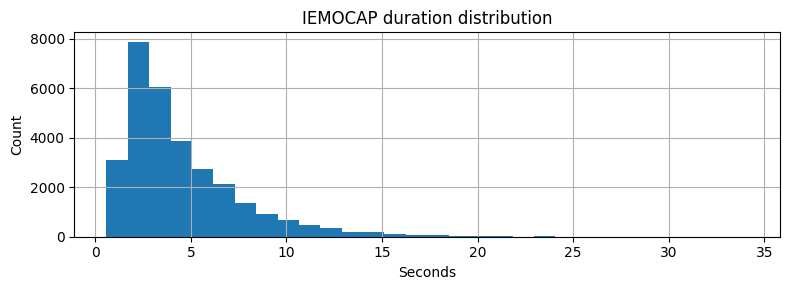

In [10]:
print('IEMOCAP emotion counts:')
display(iemocap_meta['primary_emotion'].value_counts().rename_axis('emotion').reset_index(name='count'))

plt.figure(figsize=(8, 3))
iemocap_meta['duration_sec'].hist(bins=30)
plt.title('IEMOCAP duration distribution')
plt.xlabel('Seconds')
plt.ylabel('Count')
plt.tight_layout()
plt.show()


## MELD scan and EDA

This section is only for **MELD**. It builds utterance-level metadata from the official split CSV files and links each row to the matching media file.


In [11]:
# ==========================================
# 12. MELD SCANNING (WINDOWS SAFE)
# ==========================================
def find_split_media_root(meld_root: Path, split_name: str) -> Path:
    candidates = [
        meld_root / f'{split_name}_splits',
        meld_root / split_name,
        meld_root / f'{split_name}_sents',
    ]
    for c in candidates:
        if c.exists():
            return c
    raise FileNotFoundError(f'Could not find MELD media folder for split={split_name}')


def build_meld_media_index(media_root: Path) -> dict:
    index = {}
    pattern = re.compile(r'dia(\d+)_utt(\d+)', re.IGNORECASE)
    media_files = list(media_root.rglob('*.mp4')) + list(media_root.rglob('*.wav')) + list(media_root.rglob('*.m4a'))
    for p in media_files:
        m = pattern.search(p.stem)
        if m:
            index[(int(m.group(1)), int(m.group(2)))] = p
    return index


def detect_col(df: pd.DataFrame, candidates):
    lower_map = {str(c).strip().lower(): c for c in df.columns}
    for c in candidates:
        if c.lower() in lower_map:
            return lower_map[c.lower()]
    return None


def scan_meld(meld_root: Path, csv_paths: dict) -> pd.DataFrame:
    frames = []
    for split_name, csv_path in csv_paths.items():
        media_root = find_split_media_root(meld_root, split_name)
        media_index = build_meld_media_index(media_root)
        
        # WINDOWS FIX: Force pandas to read the text using UTF-8 to prevent special character crashes
        df = pd.read_csv(csv_path, encoding='utf-8')

        dia_col = detect_col(df, ['Dialogue_ID', 'dialogue_id'])
        utt_col = detect_col(df, ['Utterance_ID', 'utterance_id'])
        emo_col = detect_col(df, ['Emotion', 'emotion'])
        speaker_col = detect_col(df, ['Speaker', 'speaker'])
        utt_text_col = detect_col(df, ['Utterance', 'utterance'])

        rows = []
        for _, row in df.iterrows():
            dia = int(row[dia_col])
            utt = int(row[utt_col])
            media_path = media_index.get((dia, utt))
            if media_path is None:
                continue
                
            info = audio_info(media_path)
            if info is None:
                continue
                
            duration, sr, channels = info
            rows.append({
                'dataset': 'MELD',
                'path': str(media_path),
                'file_id': media_path.name,
                'dialogue_id': dia,
                'utterance_id': utt,
                'speaker': str(row[speaker_col]) if speaker_col is not None else f'MELD_{dia}',
                'utterance_text': str(row[utt_text_col]) if utt_text_col is not None else '',
                'primary_emotion': normalize_emotion_name(row[emo_col]),
                'duration_sec': duration,
                'sr': sr,
                'channels': channels,
                'predefined_split': split_name,
            })
        frames.append(pd.DataFrame(rows))
        
    return pd.concat(frames, ignore_index=True) if frames else pd.DataFrame()

In [12]:
# ==========================================
# 13. MELD METADATA CACHING (WINDOWS LOCAL)
# ==========================================
# Save the cache directly in your local Group Project folder
meld_cache_path = BASE_ROOT / 'meld_meta_cached.csv'

# 1. Check if the file already exists locally
if meld_cache_path.exists():
    print(f"Found cached CSV! Loading MELD metadata instantly from local disk...\n({meld_cache_path})")
    # WINDOWS FIX: Explicitly read as utf-8
    meld_meta = pd.read_csv(meld_cache_path, encoding='utf-8')
    
# 2. If it doesn't exist, run the scan and save it
else:
    print("No cache found. Scanning MELD dataset (this may take a while)...")
    # This uses your local Windows processor to scan the files
    meld_meta = scan_meld(meld_root, meld_csv_paths)

    print(f"Scan complete! Saving MELD metadata locally to {meld_cache_path} for future use...")
    # WINDOWS FIX: Explicitly save as utf-8
    meld_meta.to_csv(meld_cache_path, index=False, encoding='utf-8')

# 3. Print the results
print('MELD rows:', meld_meta.shape)
display(meld_meta.head())

Found cached CSV! Loading MELD metadata instantly from local disk...
(C:\Users\aradh\Desktop\DATA 255 Deep Learning Tech\Group Project\meld_meta_cached.csv)
MELD rows: (13706, 12)


,dataset,path,file_id,dialogue_id,utterance_id,speaker,utterance_text,primary_emotion,duration_sec,sr,channels,predefined_split
0,MELD,C:\Users\aradh\Desktop\DATA 255 Deep Learning ...,dia0_utt0.mp4,0,0,Chandler,also I was the point person on my companys tr...,neutral,5.672333,48000,2,train
1,MELD,C:\Users\aradh\Desktop\DATA 255 Deep Learning ...,dia0_utt1.mp4,0,1,The Interviewer,You mustve had your hands full.,neutral,1.501500,48000,2,train
2,MELD,C:\Users\aradh\Desktop\DATA 255 Deep Learning ...,dia0_utt2.mp4,0,2,Chandler,That I did. That I did.,neutral,2.925000,48000,2,train
3,MELD,C:\Users\aradh\Desktop\DATA 255 Deep Learning ...,dia0_utt3.mp4,0,3,The Interviewer,So lets talk a little bit about your duties.,neutral,2.752750,48000,2,train
4,MELD,C:\Users\aradh\Desktop\DATA 255 Deep Learning ...,dia0_utt4.mp4,0,4,Chandler,My duties? All right.,surprise,6.465000,48000,2,train


MELD emotion counts:


,emotion,count
0,neutral,6434
1,happy,2308
2,surprise,1636
3,angry,1607
4,sad,1002
5,disgust,361
6,fear,358


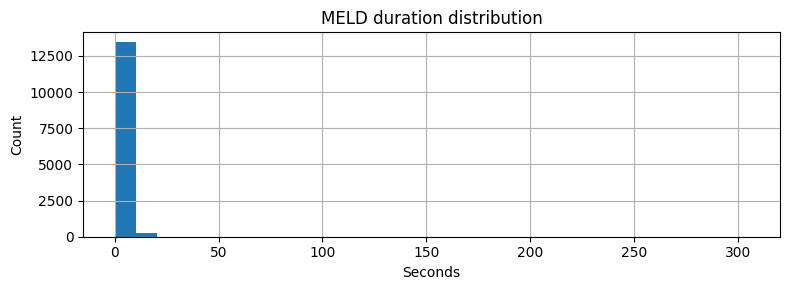

In [13]:
print('MELD emotion counts:')
display(meld_meta['primary_emotion'].value_counts().rename_axis('emotion').reset_index(name='count'))

plt.figure(figsize=(8, 3))
meld_meta['duration_sec'].hist(bins=30)
plt.title('MELD duration distribution')
plt.xlabel('Seconds')
plt.ylabel('Count')
plt.tight_layout()
plt.show()


## Shared classification label space

For the speech classifier we use a clean shared **4-class** label space:
`angry`, `happy`, `sad`, `neutral`

- **IEMOCAP** is the main training source.
- **MELD** is the external/generalization evaluation source.
- **CASE** stays separate for continuous temporal modeling.


In [14]:
# ==========================================
# 14. LABEL ALIGNMENT (IEMOCAP & MELD)
# ==========================================
import numpy as np

SHARED_LABELS = ['angry', 'happy', 'sad', 'neutral']
LABEL_TO_IDX = {name: i for i, name in enumerate(SHARED_LABELS)}
IDX_TO_LABEL = {i: name for name, i in LABEL_TO_IDX.items()}

IEMOCAP_TO_SHARED = {
    'angry': 'angry',
    'frustration': 'angry',
    'happy': 'happy',
    'sad': 'sad',
    'neutral': 'neutral',
}

MELD_TO_SHARED = {
    'angry': 'angry',
    'happy': 'happy',
    'sad': 'sad',
    'neutral': 'neutral',
}

# Map primary emotions to the shared emotion track
iemocap_meta['shared_emotion'] = iemocap_meta['primary_emotion'].map(IEMOCAP_TO_SHARED)
meld_meta['shared_emotion'] = meld_meta['primary_emotion'].map(MELD_TO_SHARED)

# Keep only the shared classes for the classification track
iemocap_cls = iemocap_meta.dropna(subset=['shared_emotion']).copy().reset_index(drop=True)
meld_cls = meld_meta.dropna(subset=['shared_emotion']).copy().reset_index(drop=True)

# Create Target Indexes
iemocap_cls['target_idx'] = iemocap_cls['shared_emotion'].map(LABEL_TO_IDX).astype(int)
meld_cls['target_idx'] = meld_cls['shared_emotion'].map(LABEL_TO_IDX).astype(int)

# Create Soft Targets (One-Hot Encoding)
iemocap_cls['soft_target'] = iemocap_cls['target_idx'].apply(lambda i: np.eye(len(SHARED_LABELS), dtype=np.float32)[i])
meld_cls['soft_target'] = meld_cls['target_idx'].apply(lambda i: np.eye(len(SHARED_LABELS), dtype=np.float32)[i])

print('IEMOCAP shared rows:', len(iemocap_cls))
print('MELD shared rows   :', len(meld_cls))
print('Label mapping      :', LABEL_TO_IDX)

IEMOCAP shared rows: 22078
MELD shared rows   : 11351
Label mapping      : {'angry': 0, 'happy': 1, 'sad': 2, 'neutral': 3}


In [15]:
# IEMOCAP split by session so train/val/test are easy to inspect
train_iemocap_df = iemocap_cls[iemocap_cls['session'].isin(['Ses01', 'Ses02', 'Ses03'])].reset_index(drop=True)
val_iemocap_df = iemocap_cls[iemocap_cls['session'] == 'Ses04'].reset_index(drop=True)
test_iemocap_df = iemocap_cls[iemocap_cls['session'] == 'Ses05'].reset_index(drop=True)

print('IEMOCAP train/val/test:', len(train_iemocap_df), len(val_iemocap_df), len(test_iemocap_df))


IEMOCAP train/val/test: 12423 4921 4734


In [16]:
# MELD official splits are preserved for evaluation and temporal context
meld_train_df = meld_cls[meld_cls['predefined_split'] == 'train'].reset_index(drop=True)
meld_dev_df = meld_cls[meld_cls['predefined_split'] == 'dev'].reset_index(drop=True)
meld_test_df = meld_cls[meld_cls['predefined_split'] == 'test'].reset_index(drop=True)

print('MELD train/dev/test:', len(meld_train_df), len(meld_dev_df), len(meld_test_df))


MELD train/dev/test: 8244 896 2211


In [17]:
# Optional runtime limits for quick debugging
USE_SMALL_SANITY_SUBSET = False
SANITY_TRAIN_ROWS = 512
SANITY_EVAL_ROWS = 256


def maybe_limit(df: pd.DataFrame, max_rows: int | None):
    if max_rows is None or len(df) <= max_rows:
        return df.reset_index(drop=True)
    return df.sample(max_rows, random_state=SEED).reset_index(drop=True)


run_train_iemocap_df = maybe_limit(train_iemocap_df, SANITY_TRAIN_ROWS if USE_SMALL_SANITY_SUBSET else None)
run_val_iemocap_df = maybe_limit(val_iemocap_df, SANITY_EVAL_ROWS if USE_SMALL_SANITY_SUBSET else None)
run_test_iemocap_df = maybe_limit(test_iemocap_df, SANITY_EVAL_ROWS if USE_SMALL_SANITY_SUBSET else None)
run_meld_dev_df = maybe_limit(meld_dev_df, SANITY_EVAL_ROWS if USE_SMALL_SANITY_SUBSET else None)
run_meld_test_df = maybe_limit(meld_test_df, SANITY_EVAL_ROWS if USE_SMALL_SANITY_SUBSET else None)

print('Run sizes -> IEMOCAP train/val/test:', len(run_train_iemocap_df), len(run_val_iemocap_df), len(run_test_iemocap_df))
print('Run sizes -> MELD dev/test         :', len(run_meld_dev_df), len(run_meld_test_df))


Run sizes -> IEMOCAP train/val/test: 12423 4921 4734
Run sizes -> MELD dev/test         : 896 2211


## Mel spectrogram + MFCC feature extraction

This section is shared by **IEMOCAP** and **MELD** only.
CASE is not used here, because CASE is handled as a continuous temporal sequence task.


In [18]:
TARGET_SR = 16000
MAX_SECONDS = 6.0
MAX_LEN = int(TARGET_SR * MAX_SECONDS)
N_MELS = 64
N_MFCC = 20
USE_MFCC_DELTAS = True
N_FFT = 1024
HOP_LENGTH = 256
BATCH_SIZE = 16
NUM_WORKERS = 0
FEATURE_MODE = 'both'   # 'logmel', 'mfcc', 'both'


In [19]:
def load_audio_fixed(path, target_sr=TARGET_SR, max_len=MAX_LEN):
    wav_path = ensure_audio_wav(Path(path), target_sr=target_sr)
    y, sr = librosa.load(str(wav_path), sr=target_sr, mono=True)
    if len(y) < max_len:
        y = np.pad(y, (0, max_len - len(y)))
    else:
        y = y[:max_len]
    return y.astype(np.float32), sr


def wav_to_logmel(y, sr=TARGET_SR):
    mel = librosa.feature.melspectrogram(y=y, sr=sr, n_mels=N_MELS, n_fft=N_FFT, hop_length=HOP_LENGTH)
    mel_db = librosa.power_to_db(mel, ref=np.max)
    return standardize_2d(mel_db)


def wav_to_mfcc(y, sr=TARGET_SR):
    mfcc = librosa.feature.mfcc(y=y, sr=sr, n_mfcc=N_MFCC, n_fft=N_FFT, hop_length=HOP_LENGTH)
    blocks = [mfcc]
    if USE_MFCC_DELTAS:
        blocks.append(librosa.feature.delta(mfcc))
        blocks.append(librosa.feature.delta(mfcc, order=2))
    stacked = np.concatenate(blocks, axis=0)
    return standardize_2d(stacked)


def extract_feature_image(path):
    y, sr = load_audio_fixed(path)
    if FEATURE_MODE == 'logmel':
        feat = wav_to_logmel(y, sr)
    elif FEATURE_MODE == 'mfcc':
        feat = wav_to_mfcc(y, sr)
    elif FEATURE_MODE == 'both':
        logmel = wav_to_logmel(y, sr)
        mfcc = wav_to_mfcc(y, sr)
        t = min(logmel.shape[1], mfcc.shape[1])
        feat = np.concatenate([logmel[:, :t], mfcc[:, :t]], axis=0)
    else:
        raise ValueError('FEATURE_MODE must be logmel, mfcc, or both')
    return feat.astype(np.float32)


In [20]:
class SpeechEmotionDataset(Dataset):
    def __init__(self, df: pd.DataFrame):
        self.df = df.reset_index(drop=True)

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        feat = extract_feature_image(row['path'])
        x = torch.tensor(feat, dtype=torch.float32).unsqueeze(0)
        hard_y = torch.tensor(int(row['target_idx']), dtype=torch.long)
        soft_y = torch.tensor(row['soft_target'], dtype=torch.float32)
        out = {
            'x': x,
            'hard_y': hard_y,
            'soft_y': soft_y,
            'label': row['shared_emotion'],
            'path': row['path'],
            'dataset': row['dataset'],
        }
        if 'dialogue_id' in row.index:
            out['dialogue_id'] = int(row['dialogue_id'])
            out['utterance_id'] = int(row['utterance_id'])
        if 'session' in row.index:
            out['session'] = row['session']
        return out


In [21]:
train_iemocap_ds = SpeechEmotionDataset(run_train_iemocap_df)
val_iemocap_ds = SpeechEmotionDataset(run_val_iemocap_df)
test_iemocap_ds = SpeechEmotionDataset(run_test_iemocap_df)

train_iemocap_loader = DataLoader(train_iemocap_ds, batch_size=BATCH_SIZE, shuffle=True, num_workers=NUM_WORKERS)
val_iemocap_loader = DataLoader(val_iemocap_ds, batch_size=BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS)
test_iemocap_loader = DataLoader(test_iemocap_ds, batch_size=BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS)

batch = next(iter(train_iemocap_loader))
print('IEMOCAP batch x shape:', batch['x'].shape)
print('IEMOCAP batch hard_y :', batch['hard_y'].shape)
print('FEATURE_MODE         :', FEATURE_MODE)


IEMOCAP batch x shape: torch.Size([16, 1, 124, 376])
IEMOCAP batch hard_y : torch.Size([16])
FEATURE_MODE         : both


In [22]:
meld_dev_ds = SpeechEmotionDataset(run_meld_dev_df)
meld_test_ds = SpeechEmotionDataset(run_meld_test_df)

meld_dev_loader = DataLoader(meld_dev_ds, batch_size=BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS)
meld_test_loader = DataLoader(meld_test_ds, batch_size=BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS)

batch = next(iter(meld_dev_loader))
print('MELD batch x shape:', batch['x'].shape)
print('MELD batch hard_y :', batch['hard_y'].shape)


MELD batch x shape: torch.Size([16, 1, 124, 376])
MELD batch hard_y : torch.Size([16])


## MELD temporal dialogue-context dataloader

This loader is separate from the utterance classifier. It keeps a short history of earlier utterances from the same dialogue so you can show temporal emotion changes across turns.


In [23]:
# ==========================================
# 16. MELD CONTEXT DATASET (WINDOWS SAFE)
# ==========================================
MELD_CONTEXT_SIZE = 3

def build_meld_context_rows(df, context_size=MELD_CONTEXT_SIZE):
    df = df.sort_values(['predefined_split', 'dialogue_id', 'utterance_id']).reset_index(drop=True)
    rows = []
    for (split_name, dialogue_id), g in df.groupby(['predefined_split', 'dialogue_id'], dropna=True):
        g = g.sort_values('utterance_id').reset_index(drop=True)
        records = g.to_dict('records')
        for i, rec in enumerate(records):
            hist = records[max(0, i - context_size):i]
            out = dict(rec)
            out['context_paths'] = [r['path'] for r in hist]
            out['context_emotions'] = [r['shared_emotion'] for r in hist]
            out['context_len'] = len(hist)
            rows.append(out)
    return pd.DataFrame(rows)

meld_context_df = build_meld_context_rows(meld_cls, context_size=MELD_CONTEXT_SIZE)
print('MELD context rows:', meld_context_df.shape)
display(meld_context_df[['predefined_split', 'dialogue_id', 'utterance_id', 'shared_emotion', 'context_len', 'context_emotions']].head())

class MELDContextDataset(Dataset):
    def __init__(self, df, context_size=MELD_CONTEXT_SIZE):
        self.context_size = int(context_size)
        self.df = build_meld_context_rows(df, context_size=context_size).reset_index(drop=True)

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        current_feat = torch.tensor(extract_feature_image(row['path']), dtype=torch.float32).unsqueeze(0)
        context_feats = []
        for p in row['context_paths'][-self.context_size:]:
            context_feats.append(torch.tensor(extract_feature_image(p), dtype=torch.float32).unsqueeze(0))
        while len(context_feats) < self.context_size:
            context_feats.insert(0, torch.zeros_like(current_feat))
        x_seq = torch.stack(context_feats + [current_feat], dim=0)

        # Pad the context_emotions list so they all have the same length
        emotions = list(row['context_emotions'][-self.context_size:])
        while len(emotions) < self.context_size:
            emotions.insert(0, 'pad')

        return {
            'x_seq': x_seq,
            'hard_y': torch.tensor(int(row['target_idx']), dtype=torch.long),
            'dialogue_id': int(row['dialogue_id']),
            'utterance_id': int(row['utterance_id']),
            'context_len': int(row['context_len']),
            'context_emotions': emotions,
        }

meld_context_run_df = maybe_limit(meld_train_df, 256 if USE_SMALL_SANITY_SUBSET else None)
meld_context_ds = MELDContextDataset(meld_context_run_df, context_size=MELD_CONTEXT_SIZE)

# WINDOWS FIX: Set num_workers=0 to prevent the infinite loading deadlock
meld_context_loader = DataLoader(meld_context_ds, batch_size=4, shuffle=True, num_workers=0)

print("Fetching sequence batch... (Should take a few seconds)")
seq_batch = next(iter(meld_context_loader))
print('MELD sequence batch x_seq shape:', seq_batch['x_seq'].shape)

MELD context rows: (11351, 18)


,predefined_split,dialogue_id,utterance_id,shared_emotion,context_len,context_emotions
0,dev,0,0,sad,0,[]
1,dev,1,0,neutral,0,[]
2,dev,1,1,happy,1,[neutral]
3,dev,1,2,sad,2,"[neutral, happy]"
4,dev,1,3,neutral,3,"[neutral, happy, sad]"


Fetching sequence batch... (Should take a few seconds)
MELD sequence batch x_seq shape: torch.Size([4, 4, 1, 124, 376])


## Small sanity-check model

The next two cells run a quick 1-epoch sanity pass on **IEMOCAP** and then evaluate the same model on **IEMOCAP validation** and **MELD**.


In [24]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

class SmallSERNet(nn.Module):
    def __init__(self, num_classes):
        super().__init__()
        self.features = nn.Sequential(
            nn.Conv2d(1, 16, kernel_size=3, padding=1),
            nn.BatchNorm2d(16),
            nn.ReLU(),
            nn.MaxPool2d(2),
            nn.Conv2d(16, 32, kernel_size=3, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(),
            nn.MaxPool2d(2),
            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(),
            nn.AdaptiveAvgPool2d((4, 4)),
        )
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(64 * 4 * 4, 128),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(128, num_classes),
        )

    def forward(self, x):
        return self.classifier(self.features(x))


def soft_cross_entropy(logits, soft_targets):
    log_probs = F.log_softmax(logits, dim=1)
    return -(soft_targets * log_probs).sum(dim=1).mean()


def run_epoch(model, loader, optimizer=None):
    train_mode = optimizer is not None
    model.train(train_mode)
    total_loss = 0.0
    total_correct = 0
    total_count = 0

    for batch in loader:
        xb = batch['x'].to(device)
        hard_y = batch['hard_y'].to(device)
        soft_y = batch['soft_y'].to(device)

        if train_mode:
            optimizer.zero_grad()

        logits = model(xb)
        loss = soft_cross_entropy(logits, soft_y)

        if train_mode:
            loss.backward()
            optimizer.step()

        preds = logits.argmax(dim=1)
        total_loss += loss.item() * xb.size(0)
        total_correct += (preds == hard_y).sum().item()
        total_count += xb.size(0)

    return total_loss / max(total_count, 1), total_correct / max(total_count, 1)


In [25]:
model = SmallSERNet(num_classes=len(SHARED_LABELS)).to(device)
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)

train_loss, train_acc = run_epoch(model, train_iemocap_loader, optimizer=optimizer)
val_loss, val_acc = run_epoch(model, val_iemocap_loader, optimizer=None)
meld_dev_loss, meld_dev_acc = run_epoch(model, meld_dev_loader, optimizer=None)

print('Device:', device)
print(f'IEMOCAP train -> loss={train_loss:.4f} acc={train_acc:.4f}')
print(f'IEMOCAP val   -> loss={val_loss:.4f} acc={val_acc:.4f}')
print(f'MELD dev      -> loss={meld_dev_loss:.4f} acc={meld_dev_acc:.4f}')


Device: cuda
IEMOCAP train -> loss=0.9301 acc=0.5300
IEMOCAP val   -> loss=0.8457 acc=0.6078
MELD dev      -> loss=6.4127 acc=0.1708


## CASE continuous temporal track

The next cells are only for **CASE**. They discover continuous annotation tables, preview the strongest candidate, and then build a sequence dataloader for temporal emotion-change modeling.


In [26]:
def robust_read_table(path: Path):
    for sep in [',', ';', '	', None]:
        try:
            if sep is None:
                return pd.read_csv(path, sep=None, engine='python')
            return pd.read_csv(path, sep=sep)
        except Exception:
            continue
    raise ValueError(f'Could not parse table: {path}')


def summarize_case_files(root: Path, max_rows: int = 30):
    rows = []
    for p in sorted(root.rglob('*')):
        if not p.is_file():
            continue
        if p.suffix.lower() not in {'.csv', '.tsv', '.txt', '.wav', '.mp4'}:
            continue
        rows.append({
            'name': p.name,
            'suffix': p.suffix.lower(),
            'parent': p.parent.name,
            'path': str(p),
            'size_mb': round(p.stat().st_size / (1024 * 1024), 3),
        })
        if len(rows) >= max_rows:
            break
    return pd.DataFrame(rows)


def score_case_table(path: Path):
    try:
        df = robust_read_table(path)
    except Exception:
        return -1
    cols = [str(c).lower() for c in df.columns]
    score = 0
    if any('time' in c for c in cols):
        score += 3
    if any('val' in c for c in cols):
        score += 3
    if any('aro' in c for c in cols):
        score += 3
    score += min(df.shape[1], 5)
    return score


def find_case_annotation_tables(root: Path):
    tables = []
    for p in root.rglob('*'):
        if p.is_file() and p.suffix.lower() in {'.csv', '.tsv', '.txt'}:
            tables.append(p)
    tables = sorted(tables, key=lambda p: (-score_case_table(p), str(p)))
    return tables


In [27]:
case_file_preview = summarize_case_files(case_root, max_rows=30)
print('CASE file preview:')
display(case_file_preview)

case_tables = find_case_annotation_tables(case_root)
print('Top CASE annotation candidates:')
display(pd.DataFrame({'path': [str(p) for p in case_tables[:15]]}))


CASE file preview:


,name,suffix,parent,path,size_mb
0,README_initialData.txt,.txt,initial,C:\Users\aradh\Desktop\DATA 255 Deep Learning ...,0.002
1,README_annotations.txt,.txt,annotations,C:\Users\aradh\Desktop\DATA 255 Deep Learning ...,0.002
2,sub_1.csv,.csv,annotations,C:\Users\aradh\Desktop\DATA 255 Deep Learning ...,0.843
3,sub_10.csv,.csv,annotations,C:\Users\aradh\Desktop\DATA 255 Deep Learning ...,0.848
4,sub_11.csv,.csv,annotations,C:\Users\aradh\Desktop\DATA 255 Deep Learning ...,0.854
5,sub_12.csv,.csv,annotations,C:\Users\aradh\Desktop\DATA 255 Deep Learning ...,0.832
6,sub_13.csv,.csv,annotations,C:\Users\aradh\Desktop\DATA 255 Deep Learning ...,0.839
7,sub_14.csv,.csv,annotations,C:\Users\aradh\Desktop\DATA 255 Deep Learning ...,0.821
8,sub_15.csv,.csv,annotations,C:\Users\aradh\Desktop\DATA 255 Deep Learning ...,0.873
9,sub_16.csv,.csv,annotations,C:\Users\aradh\Desktop\DATA 255 Deep Learning ...,0.815


Top CASE annotation candidates:


,path
0,C:\Users\aradh\Desktop\DATA 255 Deep Learning ...
1,C:\Users\aradh\Desktop\DATA 255 Deep Learning ...
2,C:\Users\aradh\Desktop\DATA 255 Deep Learning ...
3,C:\Users\aradh\Desktop\DATA 255 Deep Learning ...
4,C:\Users\aradh\Desktop\DATA 255 Deep Learning ...
5,C:\Users\aradh\Desktop\DATA 255 Deep Learning ...
6,C:\Users\aradh\Desktop\DATA 255 Deep Learning ...
7,C:\Users\aradh\Desktop\DATA 255 Deep Learning ...
8,C:\Users\aradh\Desktop\DATA 255 Deep Learning ...
9,C:\Users\aradh\Desktop\DATA 255 Deep Learning ...


In [28]:
def choose_time_column(df: pd.DataFrame):
    for c in df.columns:
        name = str(c).strip().lower()
        if 'time' in name:
            return c
    numeric_cols = [c for c in df.columns if pd.api.types.is_numeric_dtype(df[c])]
    return numeric_cols[0] if numeric_cols else None


def choose_target_columns(df: pd.DataFrame, time_col):
    preferred = []
    for c in df.columns:
        name = str(c).strip().lower()
        if c == time_col:
            continue
        if 'val' in name or 'aro' in name:
            preferred.append(c)
    if preferred:
        return preferred[:2]
    numeric_cols = [c for c in df.columns if pd.api.types.is_numeric_dtype(df[c]) and c != time_col]
    return numeric_cols[:2]


def normalize_case_table(path: Path):
    raw = robust_read_table(path)
    raw = raw.dropna(how='all').reset_index(drop=True)
    time_col = choose_time_column(raw)
    if time_col is None:
        raise ValueError(f'No usable time column found in {path}')
    target_cols = choose_target_columns(raw, time_col)
    if not target_cols:
        raise ValueError(f'No usable target columns found in {path}')

    out = pd.DataFrame({'time': pd.to_numeric(raw[time_col], errors='coerce')})
    for i, c in enumerate(target_cols, start=1):
        out[f'target_{i}'] = pd.to_numeric(raw[c], errors='coerce')
    out = out.dropna().reset_index(drop=True)
    return out, {'time_col': time_col, 'target_cols': target_cols}


Using CASE table: C:\Users\aradh\Desktop\DATA 255 Deep Learning Tech\Group Project\CASE_full\CASE_full\data\interpolated\annotations\sub_1.csv
Detected columns: {'time_col': 'jstime', 'target_cols': ['valence', 'arousal']}


,time,target_1,target_2
0,0,5.0,5.0
1,50,5.0,5.0
2,100,5.0,5.0
3,150,5.0,5.0
4,200,5.0,5.0


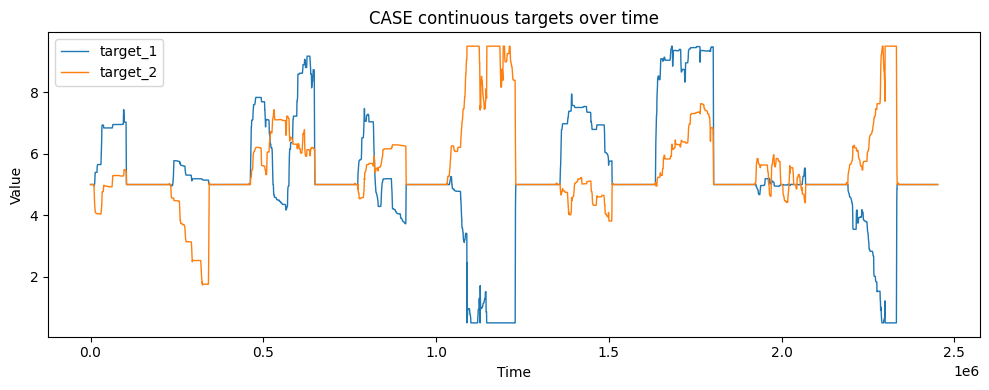

In [29]:
if not case_tables:
    raise RuntimeError('No CASE annotation tables found after extraction.')

case_table, case_info = normalize_case_table(case_tables[0])
print('Using CASE table:', case_tables[0])
print('Detected columns:', case_info)
display(case_table.head())

plt.figure(figsize=(10, 4))
for c in case_table.columns:
    if c != 'time':
        plt.plot(case_table['time'], case_table[c], label=c, linewidth=1)
plt.title('CASE continuous targets over time')
plt.xlabel('Time')
plt.ylabel('Value')
plt.legend()
plt.tight_layout()
plt.show()


In [30]:
CASE_WINDOW = 128
CASE_STRIDE = 32
CASE_BATCH_SIZE = 32


def build_case_windows(df: pd.DataFrame, window=CASE_WINDOW, stride=CASE_STRIDE):
    feat_cols = [c for c in df.columns if c != 'time']
    x_list, y_list = [], []
    values = df[feat_cols].values.astype(np.float32)
    for start in range(0, max(len(df) - window + 1, 0), stride):
        seg = values[start:start + window]
        if len(seg) < window:
            continue
        x_list.append(seg.T)
        y_list.append(seg[-1])
    if not x_list:
        return np.empty((0, len(feat_cols), window), dtype=np.float32), np.empty((0, len(feat_cols)), dtype=np.float32)
    return np.stack(x_list), np.stack(y_list)


class CASESequenceDataset(Dataset):
    def __init__(self, table_df, window=CASE_WINDOW, stride=CASE_STRIDE):
        self.feature_cols = [c for c in table_df.columns if c != 'time']
        scaler = StandardScaler()
        scaled = scaler.fit_transform(table_df[self.feature_cols].values)
        work = pd.DataFrame(scaled, columns=self.feature_cols)
        work.insert(0, 'time', table_df['time'].values)
        self.x, self.y = build_case_windows(work, window=window, stride=stride)

    def __len__(self):
        return len(self.x)

    def __getitem__(self, idx):
        return {
            'x_seq': torch.tensor(self.x[idx], dtype=torch.float32),
            'y_last': torch.tensor(self.y[idx], dtype=torch.float32),
        }


In [31]:
case_ds = CASESequenceDataset(case_table, window=CASE_WINDOW, stride=CASE_STRIDE)
case_loader = DataLoader(case_ds, batch_size=CASE_BATCH_SIZE, shuffle=True, num_workers=0)

print('CASE dataset windows:', len(case_ds))
if len(case_ds) > 0:
    case_batch = next(iter(case_loader))
    print('CASE x_seq shape:', case_batch['x_seq'].shape)
    print('CASE y_last shape:', case_batch['y_last'].shape)
else:
    print('CASE windows could not be built. Try reducing CASE_WINDOW.')


CASE dataset windows: 1529
CASE x_seq shape: torch.Size([32, 2, 128])
CASE y_last shape: torch.Size([32, 2])


## Final notebook structure recap

- **EDA**
  - IEMOCAP: utterance-level categorical distribution and duration statistics.
  - MELD: dialogue-utterance categorical distribution and duration statistics.
  - CASE: continuous target trajectory inspection.

- **Mel Spectrogram & MFCC extraction**
  - Applied to **IEMOCAP** and **MELD** only.
  - Shared audio preprocessing code keeps the feature pipeline consistent.

- **Dataloaders**
  - **IEMOCAP** utterance loader for the main classifier.
  - **MELD** utterance loader for external evaluation and a **context loader** for temporal dialogue modeling.
  - **CASE** sequence loader for continuous emotion change over time.


In [32]:
# ==========================================
# SPATIAL & TEMPORAL CORE
# ==========================================
import torch.nn.functional as F

SHARED_EMBEDDING_DIM = 256  # The shape-matching target dimension for Member 3
MEL_BINS = N_MELS           # 64
MFCC_BINS = N_MFCC * 3 if USE_MFCC_DELTAS else N_MFCC  # 60

def split_features(x_batch):
    """
    Splits Member 1's concatenated feature tensor into Mel and MFCC tensors.
    Input shape: (Batch, 1, 124, Time)
    Returns:
        mel: (Batch, 1, 64, Time)
        mfcc: (Batch, 1, 60, Time)
    """
    # Slice along the frequency dimension (dim=2)
    mel = x_batch[:, :, :MEL_BINS, :]
    mfcc = x_batch[:, :, MEL_BINS:, :]
    return mel, mfcc

In [33]:
class SpatialCNNBlock(nn.Module):
    def __init__(self, out_features=SHARED_EMBEDDING_DIM):
        super(SpatialCNNBlock, self).__init__()
        # Input shape: (Batch, 1, 64, Time)

        self.conv_blocks = nn.Sequential(
            nn.Conv2d(1, 32, kernel_size=3, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(),
            nn.MaxPool2d(2, 2),

            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(),
            nn.MaxPool2d(2, 2),

            nn.Conv2d(64, 128, kernel_size=3, padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(),

            # Forces the spatial dimensions to exactly 4x4
            nn.AdaptiveAvgPool2d((4, 4))
        )

        # Shape-matching projection
        self.fc = nn.Sequential(
            nn.Flatten(),
            nn.Linear(128 * 4 * 4, 512),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(512, out_features)
        )

    def forward(self, mel_x):
        features = self.conv_blocks(mel_x)
        embeddings = self.fc(features)
        return embeddings

In [34]:
class TemporalDenseBlock(nn.Module):
    def __init__(self, in_channels=MFCC_BINS, out_features=SHARED_EMBEDDING_DIM):
        super(TemporalDenseBlock, self).__init__()
        # Input shape from split_features: (Batch, 1, 60, Time)

        # We will collapse the time dimension using an adaptive pool
        # so we can feed it into fixed Dense/Linear layers.
        self.time_pool = nn.AdaptiveAvgPool2d((in_channels, 1))

        self.dense_blocks = nn.Sequential(
            nn.Flatten(),
            nn.Linear(in_channels, 256),
            nn.BatchNorm1d(256),
            nn.ReLU(),
            nn.Dropout(0.3),

            # Shape-matching projection
            nn.Linear(256, out_features)
        )

    def forward(self, mfcc_x):
        # mfcc_x shape: (Batch, 1, 60, Time)

        # Pool across time to get a fixed representation: (Batch, 1, 60, 1)
        pooled = self.time_pool(mfcc_x)

        # Pass through dense layers to get embedding
        embeddings = self.dense_blocks(pooled)
        return embeddings

In [35]:
# Instantiate the models and move to device
spatial_cnn = SpatialCNNBlock(out_features=SHARED_EMBEDDING_DIM).to(device)
temporal_dense = TemporalDenseBlock(in_channels=MFCC_BINS, out_features=SHARED_EMBEDDING_DIM).to(device)

# Grab a real batch from Member 1's IEMOCAP dataloader
test_batch = next(iter(train_iemocap_loader))
x_combined = test_batch['x'].to(device)

print(f"Original batch shape from Member 1: {x_combined.shape}")

# 1. Split the features
mel_tensor, mfcc_tensor = split_features(x_combined)
print(f"Split Mel shape:  {mel_tensor.shape}")
print(f"Split MFCC shape: {mfcc_tensor.shape}")

# 2. Pass through Member 2 Blocks
mel_embeddings = spatial_cnn(mel_tensor)
mfcc_embeddings = temporal_dense(mfcc_tensor)

print("\n--- Shape Matching Verification ---")
print(f"Spatial CNN Output Shape:    {mel_embeddings.shape}")
print(f"Temporal Dense Output Shape: {mfcc_embeddings.shape}")

# 3. Assert shapes match
if mel_embeddings.shape == mfcc_embeddings.shape and mel_embeddings.shape[1] == SHARED_EMBEDDING_DIM:
    print(f"\n✅ SUCCESS! Both blocks output identical dimensions: [Batch, {SHARED_EMBEDDING_DIM}].")
    print("Member 3 can now safely concatenate these vectors for Feature Fusion!")
else:
    print("\n❌ ERROR: Dimension mismatch. Check network configurations.")

Original batch shape from Member 1: torch.Size([16, 1, 124, 376])
Split Mel shape:  torch.Size([16, 1, 64, 376])
Split MFCC shape: torch.Size([16, 1, 60, 376])

--- Shape Matching Verification ---
Spatial CNN Output Shape:    torch.Size([16, 256])
Temporal Dense Output Shape: torch.Size([16, 256])

✅ SUCCESS! Both blocks output identical dimensions: [Batch, 256].
Member 3 can now safely concatenate these vectors for Feature Fusion!


In [36]:
# ==========================================
# SEQUENCE & CLASSIFICATION CORE
# ==========================================
import torch
import torch.nn as nn
import torch.nn.functional as F

class AttentionBlock(nn.Module):
    def __init__(self, hidden_dim):
        super(AttentionBlock, self).__init__()
        # Attention layer to find the most important time steps
        self.attention = nn.Sequential(
            nn.Linear(hidden_dim, hidden_dim // 2),
            nn.Tanh(),
            nn.Linear(hidden_dim // 2, 1)
        )

    def forward(self, lstm_output):
        # lstm_output shape: [Batch, Time, Hidden_Dim]
        attn_weights = self.attention(lstm_output) # [Batch, Time, 1]
        attn_weights = torch.softmax(attn_weights, dim=1)

        # Multiply weights by LSTM output to get context vector
        context = torch.sum(attn_weights * lstm_output, dim=1) # [Batch, Hidden_Dim]
        return context, attn_weights

class HybridSERModel(nn.Module):
    def __init__(self, num_classes=4):
        super(HybridSERModel, self).__init__()

        # --- SPATIAL CNN (Mel) ---
        self.mel_cnn = nn.Sequential(
            nn.Conv2d(1, 32, kernel_size=3, padding=1),
            nn.BatchNorm2d(32), nn.ReLU(), nn.MaxPool2d((2, 2)),
            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.BatchNorm2d(64), nn.ReLU(), nn.MaxPool2d((2, 2)),
            nn.Conv2d(64, 128, kernel_size=3, padding=1),
            nn.BatchNorm2d(128), nn.ReLU(), nn.MaxPool2d((2, 2))
            # Output height is now 64 / 8 = 8. Time dimension is T / 8.
        )

        # --- TEMPORAL DENSE (MFCC) ---
        self.mfcc_dense = nn.Sequential(
            nn.Linear(60, 128), # 60 MFCC bins
            nn.BatchNorm1d(128), nn.ReLU(),
            nn.Linear(128, 128), nn.ReLU()
        )

        # --- FUSION & BI-LSTM ---
        # CNN output feature size: 128 channels * 8 freq bins = 1024
        # MFCC output feature size: 128
        # Fused size = 1024 + 128 = 1152
        self.bilstm = nn.LSTM(input_size=1152, hidden_size=256,
                              num_layers=2, batch_first=True,
                              bidirectional=True, dropout=0.3)

        # --- ATTENTION & CLASSIFICATION ---
        self.attention = AttentionBlock(hidden_dim=512) # 256 * 2 (Bi-directional)

        self.fc = nn.Sequential(
            nn.Linear(512, 128),
            nn.ReLU(),
            nn.Dropout(0.4),
            nn.Linear(128, num_classes)
        )

    def forward(self, x):
        # 1. Split Features
        mel = x[:, :, :64, :]   # [B, 1, 64, T]
        mfcc = x[:, :, 64:, :]  # [B, 1, 60, T]

        # 2. Spatial CNN Block
        mel_out = self.mel_cnn(mel) # [B, 128, 8, T_reduced]
        B, C, H, W = mel_out.shape
        mel_seq = mel_out.view(B, C * H, W).permute(0, 2, 1) # [B, T_reduced, 1024]

        # 3. Temporal Dense Block
        # We need MFCC to match the T_reduced time steps of the CNN (via pooling)
        mfcc_pooled = F.adaptive_avg_pool1d(mfcc.squeeze(1), output_size=W) # [B, 60, T_reduced]
        mfcc_seq = mfcc_pooled.permute(0, 2, 1) # [B, T_reduced, 60]

        # Apply dense layers across the time sequence
        B, T, F_mfcc = mfcc_seq.shape
        mfcc_seq = mfcc_seq.reshape(-1, F_mfcc)
        mfcc_seq = self.mfcc_dense(mfcc_seq).view(B, T, 128) # [B, T_reduced, 128]

        # 4. Feature Fusion
        fused_seq = torch.cat((mel_seq, mfcc_seq), dim=-1) # [B, T_reduced, 1152]

        # 5. Bi-LSTM & Attention
        lstm_out, _ = self.bilstm(fused_seq) # lstm_out: [B, T_reduced, 512]
        context, attn_weights = self.attention(lstm_out) # context: [B, 512]

        # 6. Final Classification
        logits = self.fc(context)
        return logits

In [60]:
# ==========================================
# 1. MULTI-SUBJECT PHYSIOLOGICAL DATASET
# ==========================================

class CASEPhysioDataset(Dataset):
    def __init__(self, x_data, y_data):
        self.x = x_data
        self.y = y_data
            
    def __len__(self):
        return len(self.x)
        
    def __getitem__(self, idx):
        x_tensor = torch.tensor(self.x[idx], dtype=torch.float32)
        y_tensor = torch.tensor(self.y[idx], dtype=torch.float32)
        return {'x_seq': x_tensor, 'y_last': y_tensor}

class ContinuousPhysioModel(nn.Module):
    def __init__(self, num_physio_channels=9, num_outputs=2):
        super(ContinuousPhysioModel, self).__init__()
        self.cnn = nn.Sequential(
            nn.Conv1d(num_physio_channels, 32, kernel_size=5, padding=2),
            nn.BatchNorm1d(32), nn.ReLU(), nn.MaxPool1d(2),
            nn.Conv1d(32, 64, kernel_size=5, padding=2),
            nn.BatchNorm1d(64), nn.ReLU(), nn.MaxPool1d(2)
        )
        self.bilstm = nn.LSTM(input_size=64, hidden_size=64, 
                              num_layers=2, batch_first=True, 
                              bidirectional=True, dropout=0.4)
        self.time_distributed_fc = nn.Sequential(
            nn.Linear(128, 64), nn.ReLU(), nn.Dropout(0.5), nn.Linear(64, num_outputs)
        )

    def forward(self, x):
        cnn_out = self.cnn(x) 
        seq_in = cnn_out.permute(0, 2, 1) 
        lstm_out, _ = self.bilstm(seq_in) 
        continuous_preds = self.time_distributed_fc(lstm_out)
        return continuous_preds

# --- DATA PROCESSING FUNCTION ---
def load_and_window_subjects(subject_list, base_dir, window=128, stride=32):
    all_x, all_y = [], []
    annot_dir = base_dir / "interpolated" / "annotations"
    physio_dir = base_dir / "interpolated" / "physiological"
    
    for sub_id in subject_list:
        annot_path = annot_dir / f"sub_{sub_id}.csv"
        physio_path = physio_dir / f"sub_{sub_id}.csv"
        
        if not annot_path.exists() or not physio_path.exists():
            print(f"Skipping Subject {sub_id} (files not found)")
            continue
            
        # Load targets
        annot_df = pd.read_csv(annot_path)
        target_cols = [c for c in annot_df.columns if 'val' in c.lower() or 'aro' in c.lower()][:2]
        targets_matrix = annot_df[target_cols].values.astype(np.float32)
        
        # Load and scale physio
        physio_df = pd.read_csv(physio_path)
        physio_cols = [c for c in physio_df.columns if 'time' not in c.lower()]
        
        # Subject-specific normalization (crucial for physio data!)
        scaler = StandardScaler()
        physio_scaled = scaler.fit_transform(physio_df[physio_cols].values)
        physio_matrix = physio_scaled.T.astype(np.float32)
        
        # Build Windows for this subject
        min_time_steps = min(physio_matrix.shape[1], targets_matrix.shape[0])
        aligned_physio = physio_matrix[:, :min_time_steps]
        aligned_targets = targets_matrix[:min_time_steps, :]
        
        for start in range(0, min_time_steps - window + 1, stride):
            all_x.append(aligned_physio[:, start:start + window])
            all_y.append(aligned_targets[start + window - 1])
            
    return all_x, all_y

# --- EXECUTE DATA SPLIT ---
CASE_WINDOW = 128
CASE_STRIDE = 32
CASE_BATCH_SIZE = 64 # Increased batch size for more data
case_base_dir = Path(r"C:\Users\aradh\Desktop\DATA 255 Deep Learning Tech\Group Project\CASE_full\CASE_full\data")

# Subject-Wise Split (Total 30 Subjects)
train_subjects = list(range(1, 21))   # Subs 1 to 20
val_subjects = list(range(21, 26))    # Subs 21 to 25
test_subjects = list(range(26, 31))   # Subs 26 to 30

print("Extracting Training Data...")
x_train, y_train = load_and_window_subjects(train_subjects, case_base_dir, CASE_WINDOW, CASE_STRIDE)
print("Extracting Validation Data...")
x_val, y_val = load_and_window_subjects(val_subjects, case_base_dir, CASE_WINDOW, CASE_STRIDE)

train_loader = DataLoader(CASEPhysioDataset(x_train, y_train), batch_size=CASE_BATCH_SIZE, shuffle=True)
val_loader = DataLoader(CASEPhysioDataset(x_val, y_val), batch_size=CASE_BATCH_SIZE, shuffle=False)

print(f"\nFinal Split -> Train Windows: {len(x_train)} | Val Windows: {len(x_val)}")

Extracting Training Data...
Extracting Validation Data...

Final Split -> Train Windows: 30580 | Val Windows: 7645


In [37]:
# ==========================================
# 18. TRAINING & EVALUATION (LOCAL WINDOWS)
# ==========================================
import torch
import torch.nn as nn
import torch.optim as optim
import os

# --- PATH CONFIGURATION ---
# Save the model directly into your local Group Project folder
MODEL_SAVE_PATH = BASE_ROOT / "ser_hybrid_model_best.pth"

EPOCHS = 10
# This will automatically use your NVIDIA GPU if you have CUDA installed, otherwise CPU
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Training on device: {device}")

model = HybridSERModel(num_classes=4).to(device)
optimizer = optim.Adam(model.parameters(), lr=0.001)
criterion = nn.CrossEntropyLoss()

# --- DIAGNOSTIC CHECK ---
print(f"Training batches: {len(train_iemocap_loader)}")
print(f"Validation batches: {len(val_iemocap_loader)}")
if len(val_iemocap_loader) == 0:
    print("⚠️ WARNING: Validation dataloader is empty! Validation accuracy will show 0.0")

# Variable to keep track of the best score
best_val_acc = 0.0

print("\nStarting Training...")
for epoch in range(EPOCHS):
    model.train()
    total_loss, correct, total = 0, 0, 0

    for batch in train_iemocap_loader:
        x = batch['x'].to(device)
        y = batch['hard_y'].to(device)

        optimizer.zero_grad()
        outputs = model(x)
        loss = criterion(outputs, y)
        loss.backward()
        optimizer.step()

        total_loss += loss.item()
        preds = outputs.argmax(dim=1)
        correct += (preds == y).sum().item()
        total += y.size(0)

    # Safeguard against division by zero
    train_acc = correct / max(total, 1)
    avg_train_loss = total_loss / max(len(train_iemocap_loader), 1)

    # Validation Loop
    model.eval()
    val_correct, val_total = 0, 0
    with torch.no_grad():
        for batch in val_iemocap_loader:
            x = batch['x'].to(device)
            y = batch['hard_y'].to(device)
            preds = model(x).argmax(dim=1)
            val_correct += (preds == y).sum().item()
            val_total += y.size(0)

    # Safeguard against division by zero
    val_acc = val_correct / max(val_total, 1)

    print(f"Epoch {epoch+1}/{EPOCHS} | Train Loss: {avg_train_loss:.4f} | Train Acc: {train_acc:.4f} | Val Acc: {val_acc:.4f}")

    # --- MODEL CHECKPOINTING (Save only the BEST model) ---
    if val_acc > best_val_acc:
        print(f"    🌟 New best validation accuracy! ({best_val_acc:.4f} -> {val_acc:.4f}). Saving model...")
        best_val_acc = val_acc

        # Extract the model's brain (weights)
        best_model_state = model.state_dict()

        # Save directly to your local Windows hard drive
        try:
            # Ensure the directory exists (BASE_ROOT should already exist, but just to be perfectly safe)
            os.makedirs(MODEL_SAVE_PATH.parent, exist_ok=True)
            torch.save(best_model_state, MODEL_SAVE_PATH)
        except Exception as e:
            print(f"    ⚠️ Could not save model locally: {e}")

print(f"\n✅ Training Complete! Best Validation Accuracy: {best_val_acc:.4f}")
print(f"The best model weights are saved safely at: {MODEL_SAVE_PATH}")

Training on device: cuda
Training batches: 777
Validation batches: 308

Starting Training...
Epoch 1/10 | Train Loss: 0.9163 | Train Acc: 0.5409 | Val Acc: 0.6106
    🌟 New best validation accuracy! (0.0000 -> 0.6106). Saving model...
Epoch 2/10 | Train Loss: 0.8510 | Train Acc: 0.5768 | Val Acc: 0.6145
    🌟 New best validation accuracy! (0.6106 -> 0.6145). Saving model...
Epoch 3/10 | Train Loss: 0.7992 | Train Acc: 0.6267 | Val Acc: 0.6070
Epoch 4/10 | Train Loss: 0.7535 | Train Acc: 0.6562 | Val Acc: 0.6320
    🌟 New best validation accuracy! (0.6145 -> 0.6320). Saving model...
Epoch 5/10 | Train Loss: 0.7130 | Train Acc: 0.6812 | Val Acc: 0.6332
    🌟 New best validation accuracy! (0.6320 -> 0.6332). Saving model...
Epoch 6/10 | Train Loss: 0.6802 | Train Acc: 0.7022 | Val Acc: 0.6344
    🌟 New best validation accuracy! (0.6332 -> 0.6344). Saving model...
Epoch 7/10 | Train Loss: 0.6388 | Train Acc: 0.7291 | Val Acc: 0.6346
    🌟 New best validation accuracy! (0.6344 -> 0.6346). S

In [61]:
# ==========================================
# 2. PROPER TRAINING WITH VALIDATION
# ==========================================
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
BASE_ROOT = Path(r"C:\Users\aradh\Desktop\DATA 255 Deep Learning Tech\Group Project")
CONTINUOUS_MODEL_SAVE_PATH = BASE_ROOT / "physio_continuous_model_best.pth"

# Initialize model
continuous_model = ContinuousPhysioModel(num_physio_channels=9, num_outputs=2).to(device)
optimizer = torch.optim.Adam(continuous_model.parameters(), lr=0.001, weight_decay=1e-4)
criterion = nn.MSELoss() 

EPOCHS = 15
best_val_loss = float('inf')

print(f"\nStarting Full Training Pipeline on {device}...")
for epoch in range(EPOCHS):
    # --- TRAINING PHASE ---
    continuous_model.train()
    train_loss = 0
    for batch in train_loader:
        x = batch['x_seq'].to(device) 
        y = batch['y_last'].to(device) 
        
        optimizer.zero_grad()
        outputs = continuous_model(x)
        loss = criterion(outputs[:, -1, :], y)
        loss.backward()
        optimizer.step()
        train_loss += loss.item()
        
    avg_train_loss = train_loss / len(train_loader)
    
    # --- VALIDATION PHASE ---
    continuous_model.eval()
    val_loss = 0
    with torch.no_grad():
        for batch in val_loader:
            x = batch['x_seq'].to(device)
            y = batch['y_last'].to(device)
            outputs = continuous_model(x)
            loss = criterion(outputs[:, -1, :], y)
            val_loss += loss.item()
            
    avg_val_loss = val_loss / len(val_loader)
    
    print(f"Epoch {epoch+1}/{EPOCHS} | Train MSE: {avg_train_loss:.4f} | Val MSE: {avg_val_loss:.4f}")
    
    # Save best model based on VALIDATION loss
    if avg_val_loss < best_val_loss:
        print(f"    🌟 New best Val Loss! ({best_val_loss:.4f} -> {avg_val_loss:.4f}). Saving model...")
        best_val_loss = avg_val_loss
        torch.save(continuous_model.state_dict(), CONTINUOUS_MODEL_SAVE_PATH)

print("\n✅ Full CASE Training Complete!")


Starting Full Training Pipeline on cuda...
Epoch 1/15 | Train MSE: 3.5691 | Val MSE: 1.3264
    🌟 New best Val Loss! (inf -> 1.3264). Saving model...
Epoch 2/15 | Train MSE: 2.4504 | Val MSE: 1.3399
Epoch 3/15 | Train MSE: 2.4059 | Val MSE: 1.3260
    🌟 New best Val Loss! (1.3264 -> 1.3260). Saving model...
Epoch 4/15 | Train MSE: 2.3477 | Val MSE: 1.3285
Epoch 5/15 | Train MSE: 2.2597 | Val MSE: 1.3268
Epoch 6/15 | Train MSE: 2.1828 | Val MSE: 1.3344
Epoch 7/15 | Train MSE: 2.1229 | Val MSE: 1.3450
Epoch 8/15 | Train MSE: 2.0478 | Val MSE: 1.3475
Epoch 9/15 | Train MSE: 1.9750 | Val MSE: 1.4049
Epoch 10/15 | Train MSE: 1.9084 | Val MSE: 1.3902
Epoch 11/15 | Train MSE: 1.8619 | Val MSE: 1.4653
Epoch 12/15 | Train MSE: 1.8141 | Val MSE: 1.3868
Epoch 13/15 | Train MSE: 1.7719 | Val MSE: 1.4606
Epoch 14/15 | Train MSE: 1.7482 | Val MSE: 1.4314
Epoch 15/15 | Train MSE: 1.7060 | Val MSE: 1.5381

✅ Full CASE Training Complete!


In [38]:
# ==========================================
# 19. CROSS-CORPUS STRESS TEST (MELD LOCAL)
# ==========================================
import torch

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"DEVICE: {device}")

# 1. Initialize a fresh model
eval_model = HybridSERModel(num_classes=4).to(device)

# 2. Load your best weights directly from your local Group Project folder
print(f"Loading best model weights from: {MODEL_SAVE_PATH}")
eval_model.load_state_dict(torch.load(MODEL_SAVE_PATH, map_location=device))

# 3. Put the model in Evaluation Mode (turns off Dropout and training layers)
eval_model.eval()

print("Running MELD Cross-Corpus Stress Test...")
meld_correct, meld_total = 0, 0

# 4. Test on MELD without calculating gradients (saves memory/time)
with torch.no_grad():
    # FIX: Using your explicitly defined meld_test_loader!
    for batch in meld_test_loader:  
        x = batch['x'].to(device)
        y = batch['hard_y'].to(device)

        # Get predictions
        outputs = eval_model(x)
        preds = outputs.argmax(dim=1)

        meld_correct += (preds == y).sum().item()
        meld_total += y.size(0)

# 5. Calculate final real-world accuracy
meld_accuracy = meld_correct / max(meld_total, 1)

print(f"✅ Stress Test Complete!")
print(f"IEMOCAP-Trained Model Accuracy on Noisy MELD Data: {meld_accuracy:.4f} ({meld_accuracy * 100:.2f}%)")

DEVICE: cuda
Loading best model weights from: C:\Users\aradh\Desktop\DATA 255 Deep Learning Tech\Group Project\ser_hybrid_model_best.pth
Running MELD Cross-Corpus Stress Test...
✅ Stress Test Complete!
IEMOCAP-Trained Model Accuracy on Noisy MELD Data: 0.1850 (18.50%)


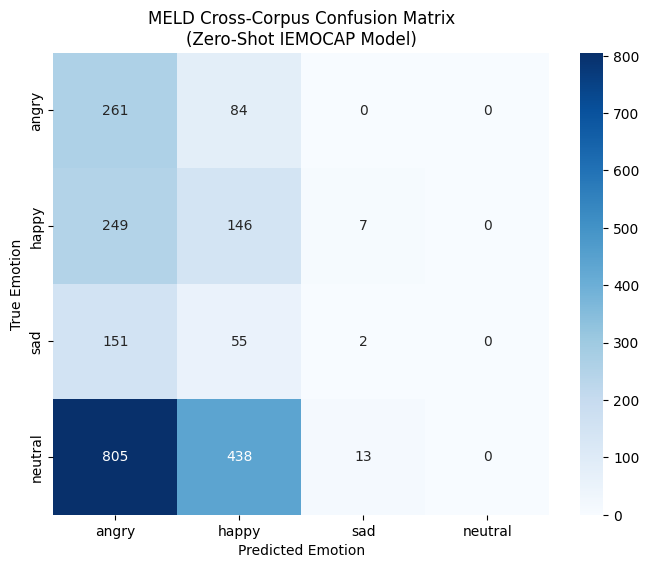


Classification Report:
              precision    recall  f1-score   support

       angry       0.18      0.76      0.29       345
       happy       0.20      0.36      0.26       402
         sad       0.09      0.01      0.02       208
     neutral       0.00      0.00      0.00      1256

    accuracy                           0.18      2211
   macro avg       0.12      0.28      0.14      2211
weighted avg       0.07      0.18      0.09      2211



In [39]:
# ==========================================
# 20. DIAGNOSTICS: MELD CONFUSION MATRIX
# ==========================================
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, classification_report
import numpy as np

# Re-run the evaluation to collect the actual predictions
eval_model.eval()
all_preds = []
all_trues = []

with torch.no_grad():
    for batch in meld_test_loader:  
        x = batch['x'].to(device)
        y = batch['hard_y'].to(device)
        outputs = eval_model(x)
        preds = outputs.argmax(dim=1)
        
        all_preds.extend(preds.cpu().numpy())
        all_trues.extend(y.cpu().numpy())

# Get the label names from your dictionary
labels = [IDX_TO_LABEL[i] for i in range(4)]

# Calculate Confusion Matrix
cm = confusion_matrix(all_trues, all_preds)

# Plotting
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=labels, yticklabels=labels)
plt.title('MELD Cross-Corpus Confusion Matrix\n(Zero-Shot IEMOCAP Model)')
plt.ylabel('True Emotion')
plt.xlabel('Predicted Emotion')
plt.show()

# Print detailed metrics
print("\nClassification Report:")
print(classification_report(all_trues, all_preds, target_names=labels, zero_division=0))

In [40]:
# ==========================================
# 21. TRANSFER LEARNING (FINE-TUNING ON MELD)
# ==========================================
import torch
import torch.nn as nn
import torch.optim as optim
import numpy as np

# 1. Load the IEMOCAP-trained model
finetune_model = HybridSERModel(num_classes=4).to(device)
finetune_model.load_state_dict(torch.load(MODEL_SAVE_PATH, map_location=device))

print("Freezing feature extraction layers...")
# 2. Freeze the CNN (Mel) and Dense (MFCC) blocks
for param in finetune_model.mel_cnn.parameters():
    param.requires_grad = False
    
for param in finetune_model.mfcc_dense.parameters():
    param.requires_grad = False

# Verify what is trainable
trainable_params = sum(p.numel() for p in finetune_model.parameters() if p.requires_grad)
print(f"Trainable parameters (LSTM + Attention + FC): {trainable_params:,}")

# 3. Handle MELD Class Imbalance (Based on your classification report support)
# Support: Angry(345), Happy(402), Sad(208), Neutral(1256)
# Inverse frequency weighting: (Total / (Num_Classes * Class_Count))
total_samples = 2211
weights = [
    total_samples / (4 * 345),   # Angry
    total_samples / (4 * 402),   # Happy
    total_samples / (4 * 208),   # Sad
    total_samples / (4 * 1256)   # Neutral
]
class_weights = torch.FloatTensor(weights).to(device)
print(f"Applied Class Weights: {weights}")

# 4. Setup Optimizer (Only pass parameters that require gradients)
optimizer = optim.Adam(filter(lambda p: p.requires_grad, finetune_model.parameters()), lr=0.0005) # Lower LR for fine-tuning
criterion = nn.CrossEntropyLoss(weight=class_weights)

# New save path for the fine-tuned model
FINETUNE_SAVE_PATH = BASE_ROOT / "ser_hybrid_model_finetuned_meld.pth"

Freezing feature extraction layers...
Trainable parameters (LSTM + Attention + FC): 4,662,405
Applied Class Weights: [1.6021739130434782, 1.375, 2.657451923076923, 0.4400875796178344]


In [44]:
# ==========================================
# 22. FINE-TUNING LOOP (MELD) - WITH PROGRESS BAR
# ==========================================
import os
import torch
from torch.utils.data import DataLoader
from tqdm import tqdm  # <-- Added for progress tracking

# 1. Ensure MELD Train Loader exists (safeguard)
if 'meld_train_loader' not in locals():
    print("Initializing MELD train dataloader...")
    meld_train_ds = SpeechEmotionDataset(meld_train_df)
    meld_train_loader = DataLoader(meld_train_ds, batch_size=BATCH_SIZE, shuffle=True, num_workers=0)

FINETUNE_EPOCHS = 8
best_finetune_acc = 0.0

print(f"\nStarting Fine-Tuning on MELD for {FINETUNE_EPOCHS} epochs...")
for epoch in range(FINETUNE_EPOCHS):
    finetune_model.train()
    total_loss, correct, total = 0, 0, 0

    # Wrap the loader in tqdm to see a live progress bar!
    train_loop = tqdm(meld_train_loader, desc=f"Epoch {epoch+1}/{FINETUNE_EPOCHS} [Train]", leave=False)
    
    for batch in train_loop:
        x = batch['x'].to(device)
        y = batch['hard_y'].to(device)

        optimizer.zero_grad()
        outputs = finetune_model(x)
        loss = criterion(outputs, y)
        loss.backward()
        optimizer.step()

        total_loss += loss.item()
        preds = outputs.argmax(dim=1)
        correct += (preds == y).sum().item()
        total += y.size(0)
        
        # Update progress bar with the current loss
        train_loop.set_postfix(loss=loss.item())

    train_acc = correct / max(total, 1)
    avg_train_loss = total_loss / max(len(meld_train_loader), 1)

    # Validation Loop using MELD Dev Set
    finetune_model.eval()
    val_correct, val_total = 0, 0
    
    val_loop = tqdm(meld_dev_loader, desc=f"Epoch {epoch+1}/{FINETUNE_EPOCHS} [Val]", leave=False)
    
    with torch.no_grad():
        for batch in val_loop:
            x = batch['x'].to(device)
            y = batch['hard_y'].to(device)
            preds = finetune_model(x).argmax(dim=1)
            val_correct += (preds == y).sum().item()
            val_total += y.size(0)

    val_acc = val_correct / max(val_total, 1)

    print(f"Epoch {epoch+1}/{FINETUNE_EPOCHS} | Train Loss: {avg_train_loss:.4f} | Train Acc: {train_acc:.4f} | Val Acc: {val_acc:.4f}")

    # Save the best fine-tuned model
    if val_acc > best_finetune_acc:
        print(f"    🌟 New best MELD validation accuracy! ({best_finetune_acc:.4f} -> {val_acc:.4f}). Saving...")
        best_finetune_acc = val_acc
        best_model_state = finetune_model.state_dict()
        
        try:
            os.makedirs(FINETUNE_SAVE_PATH.parent, exist_ok=True)
            torch.save(best_model_state, FINETUNE_SAVE_PATH)
        except Exception as e:
            print(f"    ⚠️ Could not save model locally: {e}")

print(f"\n✅ Fine-Tuning Complete! Best MELD Validation Accuracy: {best_finetune_acc:.4f}")


Starting Fine-Tuning on MELD for 8 epochs...


Epoch 1/8 | Train Loss: 1.3599 | Train Acc: 0.3378 | Val Acc: 0.2991
    🌟 New best MELD validation accuracy! (0.0000 -> 0.2991). Saving...


Epoch 2/8 | Train Loss: 1.3410 | Train Acc: 0.3327 | Val Acc: 0.3884
    🌟 New best MELD validation accuracy! (0.2991 -> 0.3884). Saving...


Epoch 3/8 | Train Loss: 1.3218 | Train Acc: 0.3518 | Val Acc: 0.4286
    🌟 New best MELD validation accuracy! (0.3884 -> 0.4286). Saving...


Epoch 4/8 | Train Loss: 1.3061 | Train Acc: 0.3694 | Val Acc: 0.3817


Epoch 5/8 | Train Loss: 1.2915 | Train Acc: 0.3765 | Val Acc: 0.3527


Epoch 6/8 | Train Loss: 1.2702 | Train Acc: 0.3977 | Val Acc: 0.3672


Epoch 7/8 | Train Loss: 1.2398 | Train Acc: 0.3863 | Val Acc: 0.3493


Epoch 8/8 | Train Loss: 1.1991 | Train Acc: 0.3993 | Val Acc: 0.4185

✅ Fine-Tuning Complete! Best MELD Validation Accuracy: 0.4286


Loading best fine-tuned weights from: C:\Users\aradh\Desktop\DATA 255 Deep Learning Tech\Group Project\ser_hybrid_model_finetuned_meld.pth
Running Final MELD Test Set Evaluation...

✅ Final Fine-Tuned MELD Test Accuracy: 0.4039 (40.39%)


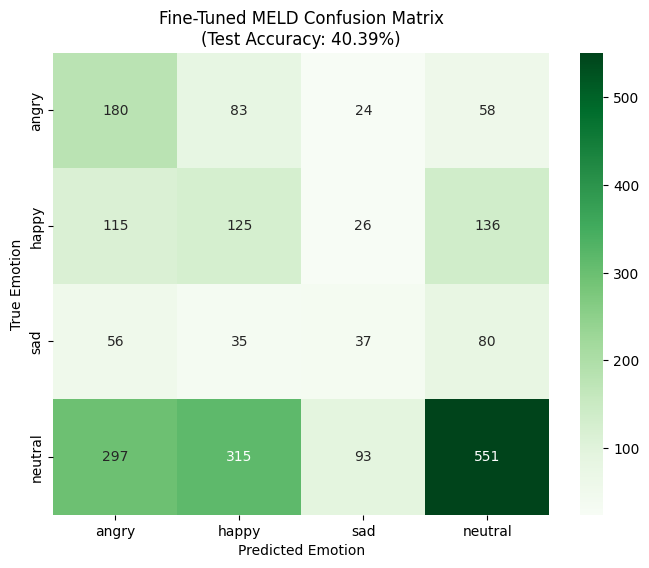


Classification Report (Fine-Tuned):
              precision    recall  f1-score   support

       angry       0.28      0.52      0.36       345
       happy       0.22      0.31      0.26       402
         sad       0.21      0.18      0.19       208
     neutral       0.67      0.44      0.53      1256

    accuracy                           0.40      2211
   macro avg       0.34      0.36      0.34      2211
weighted avg       0.48      0.40      0.42      2211



In [45]:
# ==========================================
# 23. FINAL EVALUATION: FINE-TUNED MELD TEST
# ==========================================
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, classification_report
import numpy as np
import torch

# 1. Load the BEST fine-tuned weights
print(f"Loading best fine-tuned weights from: {FINETUNE_SAVE_PATH}")
finetune_model.load_state_dict(torch.load(FINETUNE_SAVE_PATH, map_location=device))
finetune_model.eval()

all_preds_ft = []
all_trues_ft = []

print("Running Final MELD Test Set Evaluation...")
with torch.no_grad():
    # Using the TEST loader for the final unbiased score
    for batch in meld_test_loader:  
        x = batch['x'].to(device)
        y = batch['hard_y'].to(device)
        outputs = finetune_model(x)
        preds = outputs.argmax(dim=1)
        
        all_preds_ft.extend(preds.cpu().numpy())
        all_trues_ft.extend(y.cpu().numpy())

# Get the label names from your dictionary
labels = [IDX_TO_LABEL[i] for i in range(4)]

# Calculate final accuracy
ft_correct = sum(p == t for p, t in zip(all_preds_ft, all_trues_ft))
ft_accuracy = ft_correct / max(len(all_trues_ft), 1)

print(f"\n✅ Final Fine-Tuned MELD Test Accuracy: {ft_accuracy:.4f} ({ft_accuracy * 100:.2f}%)")

# Calculate Confusion Matrix
cm_ft = confusion_matrix(all_trues_ft, all_preds_ft)

# Plotting
plt.figure(figsize=(8, 6))
# Using 'Greens' this time to contrast with your first 'Blues' matrix!
sns.heatmap(cm_ft, annot=True, fmt='d', cmap='Greens', xticklabels=labels, yticklabels=labels)
plt.title(f'Fine-Tuned MELD Confusion Matrix\n(Test Accuracy: {ft_accuracy * 100:.2f}%)')
plt.ylabel('True Emotion')
plt.xlabel('Predicted Emotion')
plt.show()

# Print detailed metrics
print("\nClassification Report (Fine-Tuned):")
print(classification_report(all_trues_ft, all_preds_ft, target_names=labels, zero_division=0))

Starting overlapping inference... (Cleaning artifacts!)


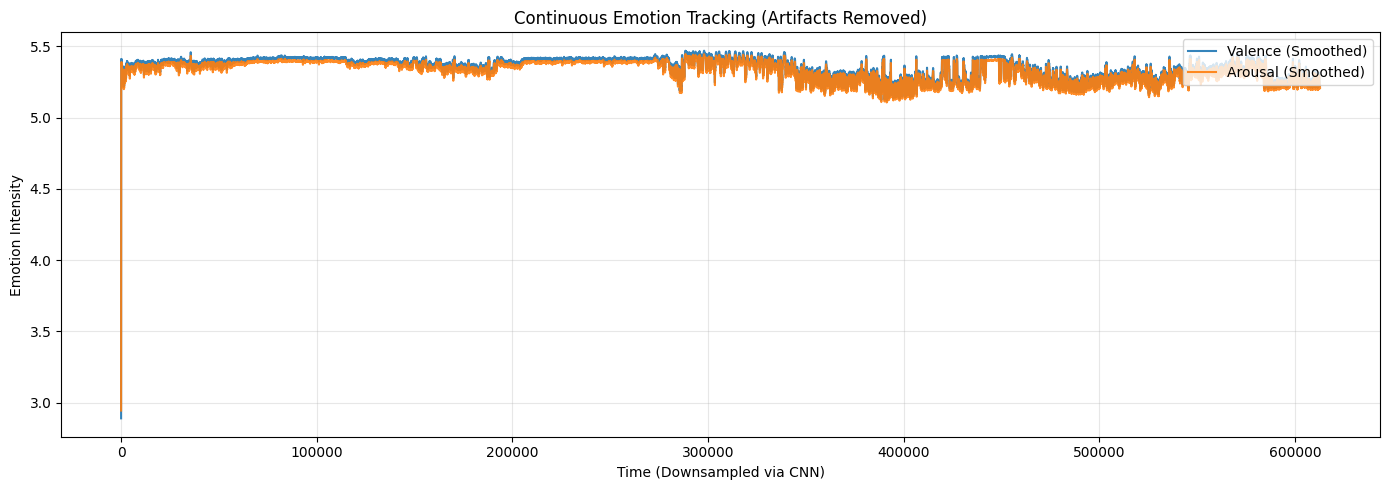

✅ Dashboard Inference Successful!


In [67]:
# ==========================================
# 3. DASHBOARD INFERENCE PIPELINE (OVERLAP & CROP)
# ==========================================
def analyze_physio_for_dashboard(physio_csv_path, scaler_obj, model, device='cuda'):
    """
    Processes physiological CSV files using overlapping chunks. 
    Trims the edge artifacts caused by LSTM hidden state resets to 
    produce a seamless, continuous emotion tracking signal.
    """
    model.eval()
    
    # 1. Load and Standardize
    df = pd.read_csv(physio_csv_path)
    cols = [c for c in df.columns if 'time' not in c.lower()]
    scaled_data = scaler_obj.transform(df[cols].values)
    physio_matrix = scaled_data.T.astype(np.float32) # [Channels, Time]
    
    total_time_steps = physio_matrix.shape[1]
    
    all_valence = []
    all_arousal = []
    
    # --- OVERLAP SETTINGS ---
    chunk_size = 12000      # Size of data passed to model at once
    overlap = 4000          # How much chunks overlap (2000 start, 2000 end)
    stride = chunk_size - overlap # How far we move forward each step (8000)
    cnn_downsample = 4      # Your 2 MaxPool layers reduce sequence length by 4
    
    # Calculate how many output predictions to trim from edges
    trim_output_steps = (overlap // 2) // cnn_downsample 
    
    with torch.no_grad():
        for start_idx in range(0, total_time_steps, stride):
            end_idx = min(start_idx + chunk_size, total_time_steps)
            chunk = physio_matrix[:, start_idx:end_idx]
            
            # Pad the very last chunk if it's too small so the CNN doesn't crash
            pad_len = chunk_size - chunk.shape[1]
            if pad_len > 0:
                chunk = np.pad(chunk, ((0, 0), (0, pad_len)), mode='edge')
            
            # Predict
            input_tensor = torch.tensor(chunk).unsqueeze(0).to(device)
            continuous_preds = model(input_tensor).squeeze(0).cpu().numpy()
            
            # --- THE FIX: CROP THE MESSY EDGES ---
            start_trim = 0 if start_idx == 0 else trim_output_steps
            
            is_last_chunk = (start_idx + stride >= total_time_steps)
            end_trim = 0 if is_last_chunk else trim_output_steps
            
            # Slice out the confident "middle" of the prediction
            if end_trim > 0:
                valid_preds = continuous_preds[start_trim : -end_trim]
            else:
                valid_preds = continuous_preds[start_trim : ]
                
            # If it's the last chunk, remove the padded garbage we added
            if is_last_chunk and pad_len > 0:
                pad_trim = pad_len // cnn_downsample
                if pad_trim > 0:
                    valid_preds = valid_preds[:-pad_trim]
            
            all_valence.extend(valid_preds[:, 0])
            all_arousal.extend(valid_preds[:, 1])
            
    return {
        "valence_tracking": np.array(all_valence),
        "arousal_tracking": np.array(all_arousal)
    }

# --- Execute and Plot ---
print("Starting overlapping inference... (Cleaning artifacts!)")
result = analyze_physio_for_dashboard(physio_path, scaler, inference_model, device)

# Optional but highly recommended: Apply a slight rolling average for visual polish
# This mimics the look of professional physiological dashboard software!
smoothing_window = 100 
valence_smooth = pd.Series(result['valence_tracking']).rolling(smoothing_window, min_periods=1).mean()
arousal_smooth = pd.Series(result['arousal_tracking']).rolling(smoothing_window, min_periods=1).mean()

plt.figure(figsize=(14, 5))
plt.plot(valence_smooth, label='Valence (Smoothed)', color='#1f77b4', alpha=0.9, linewidth=1.5)
plt.plot(arousal_smooth, label='Arousal (Smoothed)', color='#ff7f0e', alpha=0.9, linewidth=1.5)

plt.legend(loc='upper right')
plt.title('Continuous Emotion Tracking (Artifacts Removed)')
plt.xlabel('Time (Downsampled via CNN)')
plt.ylabel('Emotion Intensity')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print("✅ Dashboard Inference Successful!")